# PSX Portfolio Optimization & Financial Analytics Platform

## Project Overview

This project develops an interactive portfolio optimization and financial analytics platform using historical stock-price data from the Pakistan Stock Exchange (PSX).

The platform allows users to:

- Select multiple PSX companies from different sectors
- Enter an investment amount
- Analyze the historical return and risk of selected stocks
- Compare individual stocks with optimized portfolios
- Generate a Maximum Sharpe Ratio Portfolio
- Generate a Minimum Volatility Portfolio
- View portfolio allocations and financial performance metrics
- Analyze portfolio diversification through covariance and correlation
- Estimate hypothetical investment values based on historical performance

## Data Source

The historical stock-price data is loaded directly from the local project CSV file:

`data/sample/PSX_Sample_Data.csv`

The notebook does not require a MySQL username or password. This allows the project to be tested locally without exposing database credentials.

## Disclaimer

This project is developed for educational and analytical purposes only. Historical returns do not guarantee future investment performance, and the results should not be considered financial advice.

## 2. Import Required Libraries

This section imports the Python libraries required for:

- Data loading and manipulation
- Numerical calculations
- Portfolio optimization
- Financial performance analysis
- Data visualization
- Interactive user inputs
- File-path management

The notebook uses the local project CSV dataset and does not require a MySQL connection.

In [15]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

# Data manipulation and numerical calculations
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Portfolio optimization
from scipy.optimize import minimize

# Interactive user interface
import ipywidgets as widgets
from IPython.display import display, clear_output

# File-path management
from pathlib import Path

# Remove unnecessary warning messages
import warnings
warnings.filterwarnings("ignore")

print("All required libraries imported successfully.")

All required libraries imported successfully.


## 3. Load Historical PSX Data from the Local CSV File

This section loads the cleaned historical PSX stock-price dataset directly from the local project CSV file.

The dataset is stored in:

`data/sample/PSX_Sample_Data.csv`

The notebook automatically checks common project locations so that it can run whether the notebook is opened from the project root folder or from the `notebooks` folder.

After loading the dataset, this section displays:

- The detected CSV file location
- Total number of rows and columns
- Dataset column names
- The first five observations

In [16]:
# ==========================================
# LOAD FULL CLEANED PSX DATASET
# ==========================================

# Possible locations of the processed-data folder
possible_folders = [
    Path("data/processed"),
    Path("../data/processed"),
    Path("../../data/processed")
]

# Find the processed-data folder
processed_folder = None

for folder in possible_folders:
    if folder.exists():
        processed_folder = folder
        break

# Stop if the processed folder is not found
if processed_folder is None:
    raise FileNotFoundError(
        "The data/processed folder was not found."
    )

# Find all CSV files in the processed folder
csv_files = list(
    processed_folder.glob("*.csv")
)

# Stop if no CSV file is available
if len(csv_files) == 0:
    raise FileNotFoundError(
        "No CSV file was found inside data/processed."
    )

# Select the largest CSV file
# The full cleaned dataset should be larger than sample files
csv_path = max(
    csv_files,
    key=lambda file: file.stat().st_size
)

# Load the full cleaned PSX dataset
stock_data = pd.read_csv(
    csv_path
)

# Display dataset information
print(
    "Full cleaned PSX dataset loaded successfully."
)

print(
    f"\nLoaded file:\n{csv_path.resolve()}"
)

print(
    f"\nDataset shape: {stock_data.shape}"
)

print(
    f"Total rows: {stock_data.shape[0]:,}"
)

print(
    f"Total columns: {stock_data.shape[1]}"
)

print(
    "\nDataset columns:"
)

print(
    stock_data.columns.tolist()
)

print(
    "\nFirst five observations:"
)

display(
    stock_data.head()
)

Full cleaned PSX dataset loaded successfully.

Loaded file:
C:\Users\MOHSIN\OneDrive\Desktop\Pakistan-Stock-Market-Analytics\data\processed\PSX_2015_2025_Master_Data.csv

Dataset shape: (269825, 8)
Total rows: 269,825
Total columns: 8

Dataset columns:
['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume']

First five observations:


,Date,Symbol,Open,High,Low,Close,Adj Close,Volume
0,2015-01-01,ABL,113.250000,113.900002,112.510002,113.550003,33.938301,283800
1,2015-01-02,ABL,113.000000,115.000000,113.000000,114.029999,34.081764,508800
2,2015-01-05,ABL,114.150002,114.500000,113.599998,114.010002,34.075790,384200
3,2015-01-06,ABL,113.800003,114.750000,113.500000,113.669998,33.974163,458500
4,2015-01-07,ABL,113.550003,114.290001,113.099998,113.599998,33.953247,240400


## 4. Sector-Wise Dynamic Portfolio Selection

This section allows users to select PSX stocks across multiple sectors, enter an investment amount, and choose a portfolio optimization strategy.

In [ ]:
# ==========================================
# SECTOR-WISE DYNAMIC PORTFOLIO SELECTION
# ==========================================

# Sector-wise PSX companies
sector_stocks = {

    "Commercial Banks": {
        "ABL": "Allied Bank Limited",
        "AKBL": "Askari Bank Limited",
        "BAFL": "Bank Alfalah Limited",
        "BAHL": "Bank AL Habib Limited",
        "BOP": "The Bank of Punjab",
        "FABL": "Faysal Bank Limited",
        "HBL": "Habib Bank Limited",
        "HMB": "Habib Metropolitan Bank",
        "MCB": "MCB Bank Limited",
        "MEBL": "Meezan Bank Limited",
        "NBP": "National Bank of Pakistan",
        "SNBL": "Soneri Bank Limited",
        "UBL": "United Bank Limited"
    },

    "Oil & Gas": {
        "MARI": "Mari Energies Limited",
        "OGDC": "Oil & Gas Development Company",
        "POL": "Pakistan Oilfields Limited",
        "PPL": "Pakistan Petroleum Limited",
        "APL": "Attock Petroleum Limited",
        "HASCOL": "Hascol Petroleum Limited",
        "PSO": "Pakistan State Oil",
        "SNGP": "Sui Northern Gas Pipelines",
        "SSGC": "Sui Southern Gas Company"
    },

    "Cement": {
        "BWCL": "Bestway Cement Limited",
        "CHCC": "Cherat Cement Company",
        "DGKC": "D.G. Khan Cement Company",
        "FCCL": "Fauji Cement Company",
        "FECTC": "Fecto Cement Limited",
        "KOHC": "Kohat Cement Company",
        "LUCK": "Lucky Cement Limited",
        "MLCF": "Maple Leaf Cement Factory",
        "PIOC": "Pioneer Cement Limited"
    },

    "Fertilizer": {
        "EFERT": "Engro Fertilizers Limited",
        "ENGRO": "Engro Corporation Limited",
        "FATIMA": "Fatima Fertilizer Company",
        "FFC": "Fauji Fertilizer Company"
    },

    "Technology": {
        "SYS": "Systems Limited",
        "NETSOL": "NetSol Technologies",
        "TRG": "TRG Pakistan Limited"
    },

    "Power & Communication": {
        "PTC": "Pakistan Telecommunication Company",
        "WTL": "WorldCall Telecom",
        "HUBC": "Hub Power Company",
        "KAPCO": "Kot Addu Power Company",
        "KEL": "K-Electric Limited",
        "NCPL": "Nishat Chunian Power",
        "NPL": "Nishat Power Limited",
        "SPWL": "Saif Power Limited"
    },

    "Pharmaceutical & Chemical": {
        "ABOT": "Abbott Laboratories Pakistan",
        "AGP": "AGP Limited",
        "CPHL": "Citi Pharma Limited",
        "GLAXO": "GlaxoSmithKline Pakistan",
        "SEARL": "The Searle Company Limited",
        "COLG": "Colgate-Palmolive Pakistan",
        "LCI": "Lucky Core Industries",
        "LOTCHEM": "Lotte Chemical Pakistan"
    },

    "Automobile & Engineering": {
        "AGTL": "Al-Ghazi Tractors Limited",
        "ATLH": "Atlas Honda Limited",
        "GHNI": "Ghandhara Industries Limited",
        "GAL": "Ghandhara Automobiles Limited",
        "HCAR": "Honda Atlas Cars Pakistan",
        "INDU": "Indus Motor Company",
        "MTL": "Millat Tractors Limited",
        "SAZEW": "Sazgar Engineering Works"
    },

    "Steel": {
        "ASTL": "Amreli Steels Limited",
        "INIL": "International Industries Limited",
        "ISL": "International Steels Limited",
        "MUGHAL": "Mughal Iron & Steel Industries"
    },

    "Textile": {
        "ANL": "Azgard Nine Limited",
        "GADT": "Gadoon Textile Mills",
        "GATM": "Gul Ahmed Textile Mills",
        "ILP": "Interloop Limited",
        "NML": "Nishat Mills Limited",
        "NCL": "Nishat Chunian Limited"
    },

    "Refinery": {
        "ATRL": "Attock Refinery Limited",
        "NRL": "National Refinery Limited",
        "PRL": "Pakistan Refinery Limited"
    },

    "Food & Consumer": {
        "FFL": "Fauji Foods Limited",
        "MFL": "Mitchell's Fruit Farms",
        "NATF": "National Foods Limited",
        "NESTLE": "Nestlé Pakistan Limited",
        "RMPL": "Rafhan Maize Products",
        "UNITY": "Unity Foods Limited"
    }
}


# Standardize symbols available in the loaded CSV
available_symbols = set(
    stock_data["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(".KA", "", regex=False)
    .unique()
)


# Keep only companies available in the dataset
available_sector_stocks = {}

for sector, companies in sector_stocks.items():

    available_companies = {

        symbol: company

        for symbol, company in companies.items()

        if symbol in available_symbols
    }

    if available_companies:

        available_sector_stocks[sector] = (
            available_companies
        )


# Stores stocks selected from different sectors
saved_stocks = []


# Sector dropdown
sector_dropdown = widgets.Dropdown(

    options=[
        "Select a Sector"
    ] + list(
        available_sector_stocks.keys()
    ),

    value="Select a Sector",

    description="Sector:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="550px"
    )
)


# Company selection box
stock_selector = widgets.SelectMultiple(

    options=[],

    description="Companies:",

    rows=9,

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="700px"
    )
)


# Add selected stocks button
add_button = widgets.Button(

    description="Add Selected Stocks",

    button_style="info",

    icon="plus",

    layout=widgets.Layout(
        width="240px"
    )
)


# Saved portfolio stocks box
saved_stock_box = widgets.SelectMultiple(

    options=[],

    description="Portfolio Stocks:",

    rows=8,

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="700px"
    )
)


# Remove button
remove_button = widgets.Button(

    description="Remove Selected",

    button_style="warning",

    icon="trash",

    layout=widgets.Layout(
        width="210px"
    )
)


# Clear button
clear_button = widgets.Button(

    description="Clear All Stocks",

    button_style="danger",

    icon="remove",

    layout=widgets.Layout(
        width="210px"
    )
)


# Investment amount
investment_widget = widgets.FloatText(

    value=150000,

    description="Investment Amount (PKR):",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="450px"
    )
)


# Portfolio strategy
strategy_widget = widgets.Dropdown(

    options=[

        (
            "Maximum Sharpe Ratio",
            "max_sharpe"
        ),

        (
            "Minimum Volatility",
            "min_volatility"
        )
    ],

    value="max_sharpe",

    description="Strategy:",

    style={
        "description_width": "initial"
    },

    layout=widgets.Layout(
        width="500px"
    )
)


# Confirm portfolio button
confirm_button = widgets.Button(

    description="Confirm Portfolio",

    button_style="success",

    icon="check",

    layout=widgets.Layout(
        width="250px"
    )
)


# Message output
message_output = widgets.Output()


# Update company list when sector changes
def update_company_list(change):

    selected_sector = change["new"]

    if selected_sector == "Select a Sector":

        stock_selector.options = []

    else:

        companies = (
            available_sector_stocks[
                selected_sector
            ]
        )

        stock_selector.options = [

            (
                f"{symbol} — {company}",
                symbol
            )

            for symbol, company
            in companies.items()
        ]


sector_dropdown.observe(
    update_company_list,
    names="value"
)


# Add selected companies
def add_stocks(button):

    selected = list(
        stock_selector.value
    )

    with message_output:

        clear_output()

        if not selected:

            print(
                "Please select at least "
                "one company."
            )

            return

        for symbol in selected:

            if symbol not in saved_stocks:

                saved_stocks.append(symbol)

        saved_stock_box.options = (
            saved_stocks
        )

        print(
            "Stocks added:",
            ", ".join(selected)
        )

        print(
            f"Total portfolio stocks: "
            f"{len(saved_stocks)}"
        )


add_button.on_click(
    add_stocks
)


# Remove selected portfolio stocks
def remove_stocks(button):

    selected_to_remove = list(
        saved_stock_box.value
    )

    for symbol in selected_to_remove:

        if symbol in saved_stocks:

            saved_stocks.remove(
                symbol
            )

    saved_stock_box.options = (
        saved_stocks
    )

    with message_output:

        clear_output()

        print(
            "Selected stocks removed."
        )


remove_button.on_click(
    remove_stocks
)


# Clear complete portfolio
def clear_all_stocks(button):

    saved_stocks.clear()

    saved_stock_box.options = []

    with message_output:

        clear_output()

        print(
            "All portfolio stocks cleared."
        )


clear_button.on_click(
    clear_all_stocks
)


# Confirm final portfolio
def confirm_portfolio(button):

    global selected_symbols
    global investment_amount
    global strategy_choice

    with message_output:

        clear_output()

        if len(saved_stocks) < 2:

            print(
                "Please add at least two "
                "stocks to the portfolio."
            )

            return

        if investment_widget.value <= 0:

            print(
                "Investment amount must "
                "be greater than zero."
            )

            return

        selected_symbols = (
            saved_stocks.copy()
        )

        investment_amount = float(
            investment_widget.value
        )

        strategy_choice = (
            strategy_widget.value
        )

        strategy_name = (

            "Maximum Sharpe Ratio"

            if strategy_choice
            == "max_sharpe"

            else

            "Minimum Volatility"
        )

        print(
            "PORTFOLIO CONFIRMED"
        )

        print("-" * 50)

        print(
            "Selected Stocks:",
            ", ".join(
                selected_symbols
            )
        )

        print(
            f"Total Stocks: "
            f"{len(selected_symbols)}"
        )

        print(
            f"Investment Amount: "
            f"Rs. {investment_amount:,.2f}"
        )

        print(
            "Selected Strategy:",
            strategy_name
        )

        print(
            "\nSelection saved successfully."
        )


confirm_button.on_click(
    confirm_portfolio
)


# Display user interface
display(

    widgets.VBox([

        widgets.HTML(
            "<h3>PSX Portfolio Selection</h3>"
        ),

        widgets.HTML(
            "<b>1. Select a sector and "
            "choose companies.</b>"
        ),

        sector_dropdown,

        stock_selector,

        add_button,

        widgets.HTML(
            "<br><b>2. Selected Portfolio "
            "Stocks</b>"
        ),

        saved_stock_box,

        widgets.HBox([

            remove_button,

            clear_button

        ]),

        widgets.HTML(
            "<br><b>3. Enter investment "
            "amount and select strategy.</b>"
        ),

        investment_widget,

        strategy_widget,

        confirm_button,

        message_output

    ])
)

## 5. Selected Stock Data Preparation

This section filters the selected stocks and prepares the adjusted closing-price data for portfolio analysis.

In [35]:
# ==========================================
# FILTER AND PREPARE SELECTED STOCK DATA
# ==========================================

# Check whether the portfolio was confirmed
if "selected_symbols" not in globals():

    raise ValueError(
        "Please confirm the portfolio "
        "selection in Section 4 first."
    )


# Create a working copy of the full dataset
selected_data = stock_data.copy()


# Standardize column names
selected_data.columns = (
    selected_data.columns
    .str.strip()
)


# Convert Date column to datetime format
selected_data["Date"] = pd.to_datetime(
    selected_data["Date"],
    errors="coerce"
)


# Standardize stock symbols
selected_data["Symbol"] = (

    selected_data["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(
        ".KA",
        "",
        regex=False
    )
)


# Convert adjusted closing prices to numeric
selected_data["Adj Close"] = pd.to_numeric(

    selected_data["Adj Close"],

    errors="coerce"
)


# Keep only the stocks selected by the user
selected_data = selected_data[

    selected_data["Symbol"].isin(
        selected_symbols
    )

].copy()


# Remove rows with invalid dates or prices
selected_data = selected_data.dropna(

    subset=[
        "Date",
        "Symbol",
        "Adj Close"
    ]

)


# Remove duplicate Date-Symbol observations
selected_data = selected_data.drop_duplicates(

    subset=[
        "Date",
        "Symbol"
    ],

    keep="last"
)


# Sort observations
selected_data = selected_data.sort_values(

    by=[
        "Date",
        "Symbol"
    ]

)


# Convert long-format data into price matrix
prices_raw = selected_data.pivot(

    index="Date",

    columns="Symbol",

    values="Adj Close"

)


# Keep the user's selected stock order
prices_raw = prices_raw.reindex(

    columns=selected_symbols

)


# Sort dates from oldest to newest
prices_raw = prices_raw.sort_index()


# Remove the column-axis label
prices_raw.columns.name = None


# Display results
print(
    "Selected stock data prepared successfully."
)

print(
    f"\nSelected Stocks: "
    f"{list(prices_raw.columns)}"
)

print(
    f"Price Matrix Shape: "
    f"{prices_raw.shape}"
)

print(
    f"First Available Date: "
    f"{prices_raw.index.min().date()}"
)

print(
    f"Last Available Date: "
    f"{prices_raw.index.max().date()}"
)

print(
    "\nFirst Five Price Observations:"
)

display(
    prices_raw.head()
)

Selected stock data prepared successfully.

Selected Stocks: ['MEBL', 'KOHC', 'SYS', 'PIOC']
Price Matrix Shape: (2852, 4)
First Available Date: 2015-01-01
Last Available Date: 2025-12-31

First Five Price Observations:


,MEBL,KOHC,SYS,PIOC
Date,,,,
2015-01-01,11.648311,142.498672,NaN,54.342648
2015-01-02,11.648311,142.410553,NaN,53.689381
2015-01-05,11.648311,137.937485,NaN,53.072762
2015-01-06,11.883730,140.566956,NaN,53.213188
2015-01-07,11.883730,142.241592,NaN,52.382858


## 5. Selected Stock Data Preparation and Common-Date Alignment

This section filters the selected stocks, validates their historical data, and aligns all price observations using common trading dates.

In [36]:
# ============================================================
# 5. SELECTED STOCK DATA PREPARATION
#    MISSING VALUES AND COMMON-DATE ALIGNMENT
# ============================================================

# Check whether the user confirmed a portfolio
if "selected_symbols" not in globals():

    raise ValueError(
        "Please select and confirm the portfolio "
        "in Section 4 before running this section."
    )


# ------------------------------------------------------------
# 1. CREATE A COPY OF THE FULL DATASET
# ------------------------------------------------------------

selected_data = stock_data.copy()


# ------------------------------------------------------------
# 2. STANDARDIZE REQUIRED COLUMNS
# ------------------------------------------------------------

# Remove extra spaces from column names
selected_data.columns = (
    selected_data.columns
    .str.strip()
)


# Convert Date into datetime format
selected_data["Date"] = pd.to_datetime(

    selected_data["Date"],

    errors="coerce"
)


# Standardize stock symbols
selected_data["Symbol"] = (

    selected_data["Symbol"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.replace(
        ".KA",
        "",
        regex=False
    )
)


# Convert adjusted closing prices to numeric
selected_data["Adj Close"] = pd.to_numeric(

    selected_data["Adj Close"],

    errors="coerce"
)


# ------------------------------------------------------------
# 3. FILTER ONLY USER-SELECTED STOCKS
# ------------------------------------------------------------

selected_data = selected_data[

    selected_data["Symbol"].isin(
        selected_symbols
    )

].copy()


# Stop if no selected-stock data is found
if selected_data.empty:

    raise ValueError(

        "No historical data was found "
        "for the selected stocks."
    )


# ------------------------------------------------------------
# 4. CHECK WHETHER ALL SELECTED STOCKS EXIST
# ------------------------------------------------------------

found_symbols = (

    selected_data["Symbol"]
    .dropna()
    .unique()
    .tolist()

)


missing_symbols = [

    symbol

    for symbol in selected_symbols

    if symbol not in found_symbols

]


if missing_symbols:

    raise ValueError(

        "Historical data is unavailable "
        f"for these stocks: {missing_symbols}"
    )


# ------------------------------------------------------------
# 5. REMOVE INVALID DATE AND PRICE RECORDS
# ------------------------------------------------------------

invalid_records = (

    selected_data[
        ["Date", "Adj Close"]
    ]
    .isna()
    .any(axis=1)
    .sum()

)


selected_data = selected_data.dropna(

    subset=[
        "Date",
        "Symbol",
        "Adj Close"
    ]

)


# ------------------------------------------------------------
# 6. REMOVE DUPLICATE DATE-SYMBOL RECORDS
# ------------------------------------------------------------

duplicate_records = (

    selected_data
    .duplicated(
        subset=[
            "Date",
            "Symbol"
        ]
    )
    .sum()

)


selected_data = (

    selected_data
    .drop_duplicates(

        subset=[
            "Date",
            "Symbol"
        ],

        keep="last"
    )

)


# ------------------------------------------------------------
# 7. SORT DATA BY DATE AND STOCK SYMBOL
# ------------------------------------------------------------

selected_data = (

    selected_data
    .sort_values(

        by=[
            "Date",
            "Symbol"
        ]

    )

)


# ------------------------------------------------------------
# 8. MERGE SELECTED STOCKS BY DATE
# ------------------------------------------------------------

# Each selected stock becomes a separate column.
# Dates become the common table index.

prices_before_alignment = (

    selected_data
    .pivot(

        index="Date",

        columns="Symbol",

        values="Adj Close"

    )

)


# Keep the same stock order selected by the user
prices_before_alignment = (

    prices_before_alignment
    .reindex(
        columns=selected_symbols
    )

)


# Sort dates from oldest to newest
prices_before_alignment = (

    prices_before_alignment
    .sort_index()

)


# Remove unnecessary column-axis name
prices_before_alignment.columns.name = None


# ------------------------------------------------------------
# 9. DATA AVAILABILITY BEFORE ALIGNMENT
# ------------------------------------------------------------

availability_summary = pd.DataFrame({

    "Available Observations":

        prices_before_alignment
        .notna()
        .sum(),

    "Missing Values":

        prices_before_alignment
        .isna()
        .sum(),

    "First Available Date":

        prices_before_alignment
        .apply(
            lambda column:
            column.first_valid_index()
        ),

    "Last Available Date":

        prices_before_alignment
        .apply(
            lambda column:
            column.last_valid_index()
        )

})


# ------------------------------------------------------------
# 10. KEEP ONLY COMMON DATES
# ------------------------------------------------------------

# A date is retained only when every selected
# stock has an adjusted closing price.

prices = (

    prices_before_alignment
    .dropna(
        how="any"
    )
    .copy()

)


# ------------------------------------------------------------
# 11. VALIDATE THE ALIGNED PRICE DATA
# ------------------------------------------------------------

if prices.empty:

    raise ValueError(

        "No common trading dates were found "
        "for all selected stocks."
    )


original_date_rows = len(
    prices_before_alignment
)


common_date_rows = len(
    prices
)


rows_removed = (

    original_date_rows

    - common_date_rows

)


# ------------------------------------------------------------
# 12. DISPLAY FINAL RESULTS
# ------------------------------------------------------------

print(
    "SELECTED STOCK DATA VALIDATION"
)

print(
    "=" * 55
)


print(
    f"\nSelected Stocks: "
    f"{selected_symbols}"
)


print(
    f"Invalid Date/Price Records Removed: "
    f"{invalid_records:,}"
)


print(
    f"Duplicate Date-Symbol Records Removed: "
    f"{duplicate_records:,}"
)


print(
    "\nStock Data Availability "
    "Before Common-Date Alignment:"
)


display(
    availability_summary
)


print(
    "\nCOMMON-DATE ALIGNMENT"
)

print(
    "-" * 55
)


print(
    f"Dates Before Alignment: "
    f"{original_date_rows:,}"
)


print(
    f"Common Dates Retained: "
    f"{common_date_rows:,}"
)


print(
    f"Dates Removed: "
    f"{rows_removed:,}"
)


print(
    f"First Common Date: "
    f"{prices.index.min().date()}"
)


print(
    f"Last Common Date: "
    f"{prices.index.max().date()}"
)


print(
    "\nMissing Values After Alignment:"
)


display(

    prices
    .isna()
    .sum()
    .to_frame(
        name="Missing Values"
    )

)


print(
    "\nFinal Common-Date Price Matrix:"
)


display(
    prices.head()
)

SELECTED STOCK DATA VALIDATION

Selected Stocks: ['MEBL', 'KOHC', 'SYS', 'PIOC']
Invalid Date/Price Records Removed: 0
Duplicate Date-Symbol Records Removed: 0

Stock Data Availability Before Common-Date Alignment:


,Available Observations,Missing Values,First Available Date,Last Available Date
MEBL,2851,1,2015-01-01,2025-12-31
KOHC,2852,0,2015-01-01,2025-12-31
SYS,2818,34,2015-02-16,2025-12-31
PIOC,2851,1,2015-01-01,2025-12-31



COMMON-DATE ALIGNMENT
-------------------------------------------------------
Dates Before Alignment: 2,852
Common Dates Retained: 2,818
Dates Removed: 34
First Common Date: 2015-02-16
Last Common Date: 2025-12-31

Missing Values After Alignment:


,Missing Values
MEBL,0
KOHC,0
SYS,0
PIOC,0



Final Common-Date Price Matrix:


,MEBL,KOHC,SYS,PIOC
Date,,,,
2015-02-16,12.433041,150.636856,19.527008,50.478035
2015-02-17,12.261383,152.039719,19.161688,50.490246
2015-02-18,12.246669,150.570724,18.452524,49.928562
2015-02-19,12.133864,150.570724,19.373003,51.900551
2015-02-20,12.254025,149.101746,20.153797,50.551300


## 6. Historical Return and Risk Analysis

This section calculates the historical daily and annualized return and volatility of each selected stock.

In [37]:
# ============================================================
# 6. HISTORICAL RETURN AND RISK ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. CALCULATE DAILY RETURNS
# ------------------------------------------------------------

daily_returns = (

    prices
    .pct_change()
    .dropna()

)


# Stop if return data is unavailable
if daily_returns.empty:

    raise ValueError(

        "Daily returns could not be calculated. "
        "Please check the aligned price data."
    )


# ------------------------------------------------------------
# 2. CALCULATE DAILY RETURN AND VOLATILITY
# ------------------------------------------------------------

average_daily_return = (

    daily_returns
    .mean()

)


daily_volatility = (

    daily_returns
    .std()

)


# ------------------------------------------------------------
# 3. CALCULATE ANNUALIZED RETURN AND VOLATILITY
# ------------------------------------------------------------

# PSX generally has approximately
# 252 trading days in one year.

trading_days = 252


annual_returns = (

    average_daily_return

    * trading_days

)


annual_volatility = (

    daily_volatility

    * np.sqrt(
        trading_days
    )

)


# ------------------------------------------------------------
# 4. CREATE STOCK PERFORMANCE SUMMARY
# ------------------------------------------------------------

stock_performance = pd.DataFrame({

    "Average Daily Return":

        average_daily_return,

    "Daily Volatility":

        daily_volatility,

    "Expected Annual Return":

        annual_returns,

    "Annual Volatility":

        annual_volatility

})


# Sort stocks from highest to lowest
# expected annual return

stock_performance = (

    stock_performance
    .sort_values(

        by="Expected Annual Return",

        ascending=False

    )

)


# ------------------------------------------------------------
# 5. FORMAT RESULTS AS PERCENTAGES
# ------------------------------------------------------------

stock_performance_display = (

    stock_performance
    .copy()

)


percentage_columns = [

    "Average Daily Return",

    "Daily Volatility",

    "Expected Annual Return",

    "Annual Volatility"

]


for column in percentage_columns:

    stock_performance_display[column] = (

        stock_performance_display[column]

        .map(

            lambda value:

            f"{value * 100:.2f}%"

        )

    )


# ------------------------------------------------------------
# 6. DISPLAY RESULTS
# ------------------------------------------------------------

print(
    "INDIVIDUAL STOCK RETURN "
    "AND RISK ANALYSIS"
)

print(
    "=" * 55
)


print(
    f"\nReturn Observations: "
    f"{len(daily_returns):,}"
)


print(
    f"Analysis Period: "
    f"{daily_returns.index.min().date()} "
    f"to "
    f"{daily_returns.index.max().date()}"
)


display(

    stock_performance_display

)

INDIVIDUAL STOCK RETURN AND RISK ANALYSIS

Return Observations: 2,817
Analysis Period: 2015-02-17 to 2025-12-31


,Average Daily Return,Daily Volatility,Expected Annual Return,Annual Volatility
SYS,0.23%,8.06%,58.58%,127.96%
KOHC,0.16%,8.18%,39.92%,129.78%
MEBL,0.14%,1.78%,35.71%,28.29%
PIOC,0.11%,2.68%,27.24%,42.59%


In [38]:
# ============================================================
# 6. HISTORICAL RETURN AND RISK ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. CALCULATE DAILY RETURNS
# ------------------------------------------------------------

daily_returns = prices.pct_change()


# ------------------------------------------------------------
# 2. REMOVE SUSPICIOUS EXTREME RETURNS
# ------------------------------------------------------------

# Returns greater than +50% or less than -50%
# are treated as potential corporate-action/data anomalies
# and excluded from return and risk calculations.

extreme_return_threshold = 0.50

daily_returns = daily_returns.mask(
    daily_returns.abs() > extreme_return_threshold
)


# Remove rows where ALL stock returns are unavailable
daily_returns = daily_returns.dropna(how="all")


# Stop if return data is unavailable
if daily_returns.empty:

    raise ValueError(

        "Daily returns could not be calculated. "
        "Please check the aligned price data."
    )


# ------------------------------------------------------------
# 3. CALCULATE DAILY RETURN AND VOLATILITY
# ------------------------------------------------------------

# Pandas mean() and std() ignore NaN values by default

average_daily_return = (

    daily_returns
    .mean()

)


daily_volatility = (

    daily_returns
    .std()

)


# ------------------------------------------------------------
# 4. CALCULATE ANNUALIZED RETURN AND VOLATILITY
# ------------------------------------------------------------

# PSX generally has approximately
# 252 trading days in one year.

trading_days = 252


annual_returns = (

    average_daily_return

    * trading_days

)


annual_volatility = (

    daily_volatility

    * np.sqrt(
        trading_days
    )

)


# ------------------------------------------------------------
# 5. CREATE STOCK PERFORMANCE SUMMARY
# ------------------------------------------------------------

stock_performance = pd.DataFrame({

    "Average Daily Return":

        average_daily_return,

    "Daily Volatility":

        daily_volatility,

    "Expected Annual Return":

        annual_returns,

    "Annual Volatility":

        annual_volatility

})


# Sort stocks from highest to lowest
# expected annual return

stock_performance = (

    stock_performance
    .sort_values(

        by="Expected Annual Return",

        ascending=False

    )

)


# ------------------------------------------------------------
# 6. FORMAT RESULTS AS PERCENTAGES
# ------------------------------------------------------------

stock_performance_display = (

    stock_performance
    .copy()

)


percentage_columns = [

    "Average Daily Return",

    "Daily Volatility",

    "Expected Annual Return",

    "Annual Volatility"

]


for column in percentage_columns:

    stock_performance_display[column] = (

        stock_performance_display[column]

        .map(

            lambda value:

            f"{value * 100:.2f}%"

        )

    )


# ------------------------------------------------------------
# 7. DISPLAY RESULTS
# ------------------------------------------------------------

print(
    "INDIVIDUAL STOCK RETURN "
    "AND RISK ANALYSIS"
)

print(
    "=" * 55
)


print(
    f"\nReturn Observations: "
    f"{len(daily_returns):,}"
)


print(
    f"Analysis Period: "
    f"{daily_returns.index.min().date()} "
    f"to "
    f"{daily_returns.index.max().date()}"
)


display(

    stock_performance_display

)

INDIVIDUAL STOCK RETURN AND RISK ANALYSIS

Return Observations: 2,817
Analysis Period: 2015-02-17 to 2025-12-31


,Average Daily Return,Daily Volatility,Expected Annual Return,Annual Volatility
SYS,0.16%,2.23%,40.29%,35.41%
MEBL,0.14%,1.78%,35.71%,28.29%
PIOC,0.11%,2.68%,27.24%,42.59%
KOHC,0.07%,2.38%,18.38%,37.74%


## 7. Covariance and Correlation Analysis

This section evaluates the relationships between selected stocks and their potential diversification benefits.

In [22]:
# ============================================================
# 7. COVARIANCE AND CORRELATION ANALYSIS
# ============================================================

# ------------------------------------------------------------
# 1. CALCULATE ANNUALIZED COVARIANCE MATRIX
# ------------------------------------------------------------

cov_matrix = (

    daily_returns
    .cov()

    * trading_days

)


# ------------------------------------------------------------
# 2. CALCULATE CORRELATION MATRIX
# ------------------------------------------------------------

correlation_matrix = (

    daily_returns
    .corr()

)


# ------------------------------------------------------------
# 3. CREATE DISPLAY COPIES
# ------------------------------------------------------------

# Covariance values shown as percentages
cov_matrix_display = (

    cov_matrix

    * 100

).round(2)


# Correlation values shown as decimals
correlation_matrix_display = (

    correlation_matrix

).round(2)


# ------------------------------------------------------------
# 4. DISPLAY COVARIANCE MATRIX
# ------------------------------------------------------------

print(
    "ANNUALIZED COVARIANCE MATRIX (%)"
)

print(
    "=" * 55
)

display(
    cov_matrix_display
)


# ------------------------------------------------------------
# 5. DISPLAY CORRELATION MATRIX
# ------------------------------------------------------------

print(
    "\nCORRELATION MATRIX"
)

print(
    "=" * 55
)

display(
    correlation_matrix_display
)


# ------------------------------------------------------------
# 6. CALCULATE AVERAGE PORTFOLIO CORRELATION
# ------------------------------------------------------------

# Select only the upper-triangle values
# and exclude diagonal values of 1.00

upper_triangle = np.triu(

    np.ones(

        correlation_matrix.shape,

        dtype=bool

    ),

    k=1

)


correlation_values = (

    correlation_matrix

    .where(
        upper_triangle
    )

    .stack()

)


average_correlation = (

    correlation_values
    .mean()

)


# ------------------------------------------------------------
# 7. DISPLAY DIVERSIFICATION INTERPRETATION
# ------------------------------------------------------------

print(
    f"\nAverage Pairwise Correlation: "
    f"{average_correlation:.2f}"
)


if average_correlation < 0:

    diversification_message = (

        "Strong diversification potential: "
        "selected stocks generally move "
        "in opposite directions."

    )


elif average_correlation < 0.30:

    diversification_message = (

        "Good diversification potential: "
        "selected stocks have relatively "
        "low historical correlation."

    )


elif average_correlation < 0.60:

    diversification_message = (

        "Moderate diversification potential: "
        "selected stocks show some common "
        "price movement."

    )


else:

    diversification_message = (

        "Limited diversification potential: "
        "selected stocks have relatively "
        "high historical correlation."

    )


print(
    "Diversification Insight:"
)

print(
    diversification_message
)

ANNUALIZED COVARIANCE MATRIX (%)


,MEBL,NETSOL,MUGHAL
MEBL,7.93,3.60,3.56
NETSOL,3.60,22.76,8.17
MUGHAL,3.56,8.17,17.44



CORRELATION MATRIX


,MEBL,NETSOL,MUGHAL
MEBL,1.00,0.27,0.30
NETSOL,0.27,1.00,0.41
MUGHAL,0.30,0.41,1.00



Average Pairwise Correlation: 0.33
Diversification Insight:
Moderate diversification potential: selected stocks show some common price movement.


## 8. Portfolio Optimization Setup

This section defines the portfolio return, volatility, and Sharpe Ratio functions required for portfolio optimization.

In [23]:
# ============================================================
# 8. PORTFOLIO OPTIMIZATION SETUP
# ============================================================

# ------------------------------------------------------------
# 1. DEFINE THE RISK-FREE RATE
# ------------------------------------------------------------

# Assumed annual risk-free rate
# This value can be updated when required.

risk_free_rate = 0.10


# ------------------------------------------------------------
# 2. NUMBER OF SELECTED STOCKS
# ------------------------------------------------------------

number_of_assets = len(
    selected_symbols
)


# ------------------------------------------------------------
# 3. INITIAL EQUAL PORTFOLIO WEIGHTS
# ------------------------------------------------------------

initial_weights = np.array(

    [
        1 / number_of_assets
    ]

    * number_of_assets

)


# ------------------------------------------------------------
# 4. PORTFOLIO EXPECTED RETURN FUNCTION
# ------------------------------------------------------------

def calculate_portfolio_return(
    weights
):

    portfolio_return = np.dot(

        weights,

        annual_returns.loc[
            selected_symbols
        ].values

    )

    return portfolio_return


# ------------------------------------------------------------
# 5. PORTFOLIO VOLATILITY FUNCTION
# ------------------------------------------------------------

def calculate_portfolio_volatility(
    weights
):

    portfolio_variance = np.dot(

        weights.T,

        np.dot(

            cov_matrix.loc[

                selected_symbols,

                selected_symbols

            ].values,

            weights

        )

    )

    portfolio_volatility = np.sqrt(

        portfolio_variance

    )

    return portfolio_volatility


# ------------------------------------------------------------
# 6. PORTFOLIO SHARPE RATIO FUNCTION
# ------------------------------------------------------------

def calculate_sharpe_ratio(
    weights
):

    portfolio_return = (

        calculate_portfolio_return(
            weights
        )

    )

    portfolio_volatility = (

        calculate_portfolio_volatility(
            weights
        )

    )

    sharpe_ratio = (

        portfolio_return

        - risk_free_rate

    ) / portfolio_volatility


    return sharpe_ratio


# ------------------------------------------------------------
# 7. NEGATIVE SHARPE RATIO
# ------------------------------------------------------------

# scipy.optimize minimizes functions.
# Therefore, the negative Sharpe Ratio
# is minimized to obtain the maximum
# positive Sharpe Ratio.

def negative_sharpe_ratio(
    weights
):

    return -calculate_sharpe_ratio(
        weights
    )


# ------------------------------------------------------------
# 8. PORTFOLIO CONSTRAINT
# ------------------------------------------------------------

# The sum of all portfolio weights
# must be equal to 100%.

constraints = {

    "type": "eq",

    "fun": lambda weights:

    np.sum(weights) - 1

}


# ------------------------------------------------------------
# 9. PORTFOLIO WEIGHT BOUNDS
# ------------------------------------------------------------

# No short selling:
# every stock weight remains
# between 0% and 100%.

bounds = tuple(

    (0, 1)

    for asset

    in range(
        number_of_assets
    )

)


# ------------------------------------------------------------
# 10. DISPLAY OPTIMIZATION SETTINGS
# ------------------------------------------------------------

print(
    "PORTFOLIO OPTIMIZATION SETUP"
)

print(
    "=" * 55
)


print(
    f"\nNumber of Selected Stocks: "
    f"{number_of_assets}"
)


print(
    f"Annual Risk-Free Rate: "
    f"{risk_free_rate * 100:.2f}%"
)


print(
    "Short Selling Allowed: No"
)


print(
    "Total Portfolio Weight: 100%"
)


print(
    "\nInitial Equal Weights:"
)


initial_weights_display = pd.DataFrame({

    "Stock":

        selected_symbols,

    "Initial Weight":

        [

            f"{weight * 100:.2f}%"

            for weight

            in initial_weights

        ]

})


display(
    initial_weights_display
)

PORTFOLIO OPTIMIZATION SETUP

Number of Selected Stocks: 3
Annual Risk-Free Rate: 10.00%
Short Selling Allowed: No
Total Portfolio Weight: 100%

Initial Equal Weights:


,Stock,Initial Weight
0,MEBL,33.33%
1,NETSOL,33.33%
2,MUGHAL,33.33%


## 9. Maximum Sharpe Ratio Portfolio

This section identifies the portfolio allocation that maximizes risk-adjusted return.

In [24]:
# ============================================================
# 9. MAXIMUM SHARPE RATIO PORTFOLIO OPTIMIZATION
# ============================================================

# ------------------------------------------------------------
# 1. RUN MAXIMUM SHARPE OPTIMIZATION
# ------------------------------------------------------------

max_sharpe_result = minimize(

    negative_sharpe_ratio,

    initial_weights,

    method="SLSQP",

    bounds=bounds,

    constraints=constraints

)


# ------------------------------------------------------------
# 2. CHECK OPTIMIZATION SUCCESS
# ------------------------------------------------------------

if not max_sharpe_result.success:

    raise ValueError(

        "Maximum Sharpe optimization failed: "

        + max_sharpe_result.message

    )


# ------------------------------------------------------------
# 3. EXTRACT OPTIMIZED WEIGHTS
# ------------------------------------------------------------

max_sharpe_weights = (

    max_sharpe_result.x

)


# Remove extremely small numerical values
max_sharpe_weights[

    np.abs(
        max_sharpe_weights
    ) < 1e-6

] = 0


# Normalize weights to exactly 100%
max_sharpe_weights = (

    max_sharpe_weights

    / max_sharpe_weights.sum()

)


# ------------------------------------------------------------
# 4. CALCULATE PORTFOLIO PERFORMANCE
# ------------------------------------------------------------

max_sharpe_return = (

    calculate_portfolio_return(

        max_sharpe_weights

    )

)


max_sharpe_volatility = (

    calculate_portfolio_volatility(

        max_sharpe_weights

    )

)


max_sharpe_ratio = (

    calculate_sharpe_ratio(

        max_sharpe_weights

    )

)


# ------------------------------------------------------------
# 5. CALCULATE PKR ALLOCATION
# ------------------------------------------------------------

max_sharpe_allocation = (

    max_sharpe_weights

    * investment_amount

)


# ------------------------------------------------------------
# 6. CREATE ALLOCATION TABLE
# ------------------------------------------------------------

max_sharpe_portfolio = pd.DataFrame({

    "Stock":

        selected_symbols,

    "Weight":

        max_sharpe_weights,

    "Allocation (PKR)":

        max_sharpe_allocation

})


# Sort from highest to lowest allocation
max_sharpe_portfolio = (

    max_sharpe_portfolio

    .sort_values(

        by="Weight",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


# ------------------------------------------------------------
# 7. CREATE DISPLAY TABLE
# ------------------------------------------------------------

max_sharpe_display = (

    max_sharpe_portfolio

    .copy()

)


max_sharpe_display["Weight"] = (

    max_sharpe_display["Weight"]

    .map(

        lambda value:

        f"{value * 100:.2f}%"

    )

)


max_sharpe_display[

    "Allocation (PKR)"

] = (

    max_sharpe_display[

        "Allocation (PKR)"

    ]

    .map(

        lambda value:

        f"Rs. {value:,.2f}"

    )

)


# ------------------------------------------------------------
# 8. DISPLAY OPTIMIZED PORTFOLIO
# ------------------------------------------------------------

print(
    "MAXIMUM SHARPE RATIO PORTFOLIO"
)

print(
    "=" * 55
)


print(

    f"\nExpected Annual Return: "

    f"{max_sharpe_return * 100:.2f}%"

)


print(

    f"Annual Volatility: "

    f"{max_sharpe_volatility * 100:.2f}%"

)


print(

    f"Sharpe Ratio: "

    f"{max_sharpe_ratio:.2f}"

)


print(

    f"Total Investment: "

    f"Rs. {investment_amount:,.2f}"

)


print(

    "\nOptimized Portfolio Allocation:"

)


display(

    max_sharpe_display

)

MAXIMUM SHARPE RATIO PORTFOLIO

Expected Annual Return: 35.96%
Annual Volatility: 26.70%
Sharpe Ratio: 0.97
Total Investment: Rs. 150,000.00

Optimized Portfolio Allocation:


,Stock,Weight,Allocation (PKR)
0,MEBL,87.74%,"Rs. 131,617.17"
1,MUGHAL,12.26%,"Rs. 18,382.83"
2,NETSOL,0.00%,Rs. 0.00


## 10. Minimum Volatility Portfolio

This section identifies the portfolio allocation that minimizes overall investment risk.

In [25]:
# ============================================================
# 10. MINIMUM VOLATILITY PORTFOLIO OPTIMIZATION
# ============================================================

# ------------------------------------------------------------
# 1. RUN MINIMUM VOLATILITY OPTIMIZATION
# ------------------------------------------------------------

min_vol_result = minimize(

    calculate_portfolio_volatility,

    initial_weights,

    method="SLSQP",

    bounds=bounds,

    constraints=constraints

)


# ------------------------------------------------------------
# 2. CHECK OPTIMIZATION SUCCESS
# ------------------------------------------------------------

if not min_vol_result.success:

    raise ValueError(

        "Minimum Volatility optimization failed: "

        + min_vol_result.message

    )


# ------------------------------------------------------------
# 3. EXTRACT OPTIMIZED WEIGHTS
# ------------------------------------------------------------

min_vol_weights = (

    min_vol_result.x

)


# Remove extremely small numerical values
min_vol_weights[

    np.abs(
        min_vol_weights
    ) < 1e-6

] = 0


# Normalize weights to exactly 100%
min_vol_weights = (

    min_vol_weights

    / min_vol_weights.sum()

)


# ------------------------------------------------------------
# 4. CALCULATE PORTFOLIO PERFORMANCE
# ------------------------------------------------------------

min_vol_return = (

    calculate_portfolio_return(

        min_vol_weights

    )

)


min_volatility = (

    calculate_portfolio_volatility(

        min_vol_weights

    )

)


min_vol_sharpe = (

    calculate_sharpe_ratio(

        min_vol_weights

    )

)


# ------------------------------------------------------------
# 5. CALCULATE PKR ALLOCATION
# ------------------------------------------------------------

min_vol_allocation = (

    min_vol_weights

    * investment_amount

)


# ------------------------------------------------------------
# 6. CREATE ALLOCATION TABLE
# ------------------------------------------------------------

min_vol_portfolio = pd.DataFrame({

    "Stock":

        selected_symbols,

    "Weight":

        min_vol_weights,

    "Allocation (PKR)":

        min_vol_allocation

})


# Sort stocks from highest to lowest weight
min_vol_portfolio = (

    min_vol_portfolio

    .sort_values(

        by="Weight",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


# ------------------------------------------------------------
# 7. CREATE DISPLAY TABLE
# ------------------------------------------------------------

min_vol_display = (

    min_vol_portfolio

    .copy()

)


# Convert decimal weights into percentages
min_vol_display["Weight"] = (

    min_vol_display["Weight"]

    .map(

        lambda value:

        f"{value * 100:.2f}%"

    )

)


# Format investment allocation in PKR
min_vol_display[

    "Allocation (PKR)"

] = (

    min_vol_display[

        "Allocation (PKR)"

    ]

    .map(

        lambda value:

        f"Rs. {value:,.2f}"

    )

)


# ------------------------------------------------------------
# 8. DISPLAY OPTIMIZED PORTFOLIO
# ------------------------------------------------------------

print(
    "MINIMUM VOLATILITY PORTFOLIO"
)

print(
    "=" * 55
)


print(

    f"\nExpected Annual Return: "

    f"{min_vol_return * 100:.2f}%"

)


print(

    f"Annual Volatility: "

    f"{min_volatility * 100:.2f}%"

)


print(

    f"Sharpe Ratio: "

    f"{min_vol_sharpe:.2f}"

)


print(

    f"Total Investment: "

    f"Rs. {investment_amount:,.2f}"

)


print(

    "\nOptimized Portfolio Allocation:"

)


display(

    min_vol_display

)

MINIMUM VOLATILITY PORTFOLIO

Expected Annual Return: 33.97%
Annual Volatility: 25.75%
Sharpe Ratio: 0.93
Total Investment: Rs. 150,000.00

Optimized Portfolio Allocation:


,Stock,Weight,Allocation (PKR)
0,MEBL,70.19%,"Rs. 105,286.42"
1,MUGHAL,18.35%,"Rs. 27,519.36"
2,NETSOL,11.46%,"Rs. 17,194.22"


## 11. Portfolio Strategy Comparison

This section compares the risk, return, Sharpe Ratio, and hypothetical investment values of both optimized portfolio strategies.

In [26]:
# ============================================================
# 11. PORTFOLIO STRATEGY COMPARISON
# ============================================================

# ------------------------------------------------------------
# 1. CALCULATE HYPOTHETICAL VALUE AFTER 1 YEAR
# ------------------------------------------------------------

max_sharpe_value_1y = (

    investment_amount

    * (1 + max_sharpe_return)

)


min_vol_value_1y = (

    investment_amount

    * (1 + min_vol_return)

)


# ------------------------------------------------------------
# 2. CALCULATE HYPOTHETICAL VALUE AFTER 5 YEARS
# ------------------------------------------------------------

# Compound-growth assumption:
# Future Value = Investment × (1 + Annual Return)^Years

max_sharpe_value_5y = (

    investment_amount

    * (
        1 + max_sharpe_return
    ) ** 5

)


min_vol_value_5y = (

    investment_amount

    * (
        1 + min_vol_return
    ) ** 5

)


# ------------------------------------------------------------
# 3. CREATE NUMERIC COMPARISON TABLE
# ------------------------------------------------------------

portfolio_comparison = pd.DataFrame({

    "Maximum Sharpe Portfolio": [

        max_sharpe_return,

        max_sharpe_volatility,

        max_sharpe_ratio,

        investment_amount,

        max_sharpe_value_1y,

        max_sharpe_value_5y

    ],

    "Minimum Volatility Portfolio": [

        min_vol_return,

        min_volatility,

        min_vol_sharpe,

        investment_amount,

        min_vol_value_1y,

        min_vol_value_5y

    ]

},

index=[

    "Expected Annual Return",

    "Annual Volatility",

    "Sharpe Ratio",

    "Initial Investment",

    "Hypothetical Value After 1 Year",

    "Hypothetical Value After 5 Years"

])


# ------------------------------------------------------------
# 4. CREATE A FORMATTED DISPLAY TABLE
# ------------------------------------------------------------

# Convert the copied table to object type
# so percentages and PKR text can be stored safely

portfolio_comparison_display = (
    portfolio_comparison
    .copy()
    .astype("object")
)


# Format return and volatility as percentages

for metric in [

    "Expected Annual Return",

    "Annual Volatility"

]:

    portfolio_comparison_display.loc[metric] = (

        portfolio_comparison

        .loc[metric]

        .map(

            lambda value:

            f"{float(value) * 100:.2f}%"

        )

    )


# Format Sharpe Ratio

portfolio_comparison_display.loc[

    "Sharpe Ratio"

] = (

    portfolio_comparison

    .loc["Sharpe Ratio"]

    .map(

        lambda value:

        f"{float(value):.2f}"

    )

)


# Format investment values in PKR

for metric in [

    "Initial Investment",

    "Hypothetical Value After 1 Year",

    "Hypothetical Value After 5 Years"

]:

    portfolio_comparison_display.loc[metric] = (

        portfolio_comparison

        .loc[metric]

        .map(

            lambda value:

            f"Rs. {float(value):,.2f}"

        )

    )


# ------------------------------------------------------------
# 5. DISPLAY STRATEGY COMPARISON
# ------------------------------------------------------------

print(
    "OPTIMIZED PORTFOLIO STRATEGY COMPARISON"
)

print(
    "=" * 65
)


display(

    portfolio_comparison_display

)


# ------------------------------------------------------------
# 6. DISPLAY AUTOMATED COMPARISON INSIGHT
# ------------------------------------------------------------

print(
    "\nPORTFOLIO INSIGHT"
)

print(
    "-" * 65
)


if max_sharpe_ratio > min_vol_sharpe:

    print(

        "The Maximum Sharpe Portfolio provides "
        "the higher historical risk-adjusted return."

    )


elif min_vol_sharpe > max_sharpe_ratio:

    print(

        "The Minimum Volatility Portfolio provides "
        "the higher historical risk-adjusted return."

    )


else:

    print(

        "Both portfolios have the same "
        "historical risk-adjusted return."

    )


print(

    "The Minimum Volatility Portfolio is designed "
    "to minimize overall portfolio risk."

)


print(

    "\nNote: The 1-year and 5-year values are "
    "hypothetical estimates based on historical "
    "annualized returns and are not financial forecasts."

)

OPTIMIZED PORTFOLIO STRATEGY COMPARISON


,Maximum Sharpe Portfolio,Minimum Volatility Portfolio
Expected Annual Return,35.96%,33.97%
Annual Volatility,26.70%,25.75%
Sharpe Ratio,0.97,0.93
Initial Investment,"Rs. 150,000.00","Rs. 150,000.00"
Hypothetical Value After 1 Year,"Rs. 203,937.12","Rs. 200,958.45"
Hypothetical Value After 5 Years,"Rs. 696,813.23","Rs. 647,390.52"



PORTFOLIO INSIGHT
-----------------------------------------------------------------
The Maximum Sharpe Portfolio provides the higher historical risk-adjusted return.
The Minimum Volatility Portfolio is designed to minimize overall portfolio risk.

Note: The 1-year and 5-year values are hypothetical estimates based on historical annualized returns and are not financial forecasts.


## Individual Stocks and Optimized Portfolio Comparison

This section compares the historical risk-return performance of each user-selected stock with the two optimized portfolio strategies.

The comparison includes:

- Expected Annual Return
- Annual Volatility
- Sharpe Ratio
- Initial Investment
- Hypothetical Value After 1 Year
- Hypothetical Value After 5 Years

> **Note:** Future values are hypothetical projections based on historical annualized returns and are not guaranteed future outcomes.

In [27]:
# ============================================================
# INDIVIDUAL STOCKS AND OPTIMIZED PORTFOLIO COMPARISON
# ============================================================

# ------------------------------------------------------------
# 1. CREATE AN EMPTY LIST FOR ALL RESULTS
# ------------------------------------------------------------

comparison_results = []


# ------------------------------------------------------------
# 2. CALCULATE EACH INDIVIDUAL STOCK'S PERFORMANCE
# ------------------------------------------------------------

for stock in selected_symbols:

    # Historical expected annual return
    stock_return = annual_returns.loc[stock]

    # Historical annual volatility
    stock_volatility = annual_volatility.loc[stock]

    # Calculate the individual stock Sharpe Ratio
    stock_sharpe = (

        stock_return - risk_free_rate

    ) / stock_volatility


    # Hypothetical value after one year
    stock_value_1y = (

        investment_amount

        * (1 + stock_return)

    )


    # Hypothetical value after five years
    stock_value_5y = (

        investment_amount

        * (1 + stock_return) ** 5

    )


    # Add the individual stock results
    comparison_results.append({

        "Investment Option":

            stock,

        "Type":

            "Individual Stock",

        "Expected Annual Return":

            stock_return,

        "Annual Volatility":

            stock_volatility,

        "Sharpe Ratio":

            stock_sharpe,

        "Initial Investment":

            investment_amount,

        "Hypothetical Value After 1 Year":

            stock_value_1y,

        "Hypothetical Value After 5 Years":

            stock_value_5y

    })


# ------------------------------------------------------------
# 3. ADD THE MAXIMUM SHARPE PORTFOLIO
# ------------------------------------------------------------

comparison_results.append({

    "Investment Option":

        "Maximum Sharpe Portfolio",

    "Type":

        "Optimized Portfolio",

    "Expected Annual Return":

        max_sharpe_return,

    "Annual Volatility":

        max_sharpe_volatility,

    "Sharpe Ratio":

        max_sharpe_ratio,

    "Initial Investment":

        investment_amount,

    "Hypothetical Value After 1 Year":

        max_sharpe_value_1y,

    "Hypothetical Value After 5 Years":

        max_sharpe_value_5y

})


# ------------------------------------------------------------
# 4. ADD THE MINIMUM VOLATILITY PORTFOLIO
# ------------------------------------------------------------

comparison_results.append({

    "Investment Option":

        "Minimum Volatility Portfolio",

    "Type":

        "Optimized Portfolio",

    "Expected Annual Return":

        min_vol_return,

    "Annual Volatility":

        min_volatility,

    "Sharpe Ratio":

        min_vol_sharpe,

    "Initial Investment":

        investment_amount,

    "Hypothetical Value After 1 Year":

        min_vol_value_1y,

    "Hypothetical Value After 5 Years":

        min_vol_value_5y

})


# ------------------------------------------------------------
# 5. CREATE THE NUMERIC COMPARISON TABLE
# ------------------------------------------------------------

complete_comparison = pd.DataFrame(

    comparison_results

)


# ------------------------------------------------------------
# 6. SORT BY SHARPE RATIO
# ------------------------------------------------------------

complete_comparison = (

    complete_comparison

    .sort_values(

        by="Sharpe Ratio",

        ascending=False

    )

    .reset_index(

        drop=True

    )

)


# ------------------------------------------------------------
# 7. CREATE A FORMATTED DISPLAY COPY
# ------------------------------------------------------------

complete_comparison_display = (

    complete_comparison

    .copy()

    .astype("object")

)


# Format return and volatility as percentages

for column in [

    "Expected Annual Return",

    "Annual Volatility"

]:

    complete_comparison_display[column] = (

        complete_comparison[column]

        .map(

            lambda value:

            f"{float(value) * 100:.2f}%"

        )

    )


# Format the Sharpe Ratio

complete_comparison_display[

    "Sharpe Ratio"

] = (

    complete_comparison[

        "Sharpe Ratio"

    ]

    .map(

        lambda value:

        f"{float(value):.2f}"

    )

)


# Format all investment values in PKR

for column in [

    "Initial Investment",

    "Hypothetical Value After 1 Year",

    "Hypothetical Value After 5 Years"

]:

    complete_comparison_display[column] = (

        complete_comparison[column]

        .map(

            lambda value:

            f"Rs. {float(value):,.2f}"

        )

    )


# ------------------------------------------------------------
# 8. DISPLAY THE COMPLETE COMPARISON
# ------------------------------------------------------------

print(

    "INDIVIDUAL STOCKS VS OPTIMIZED PORTFOLIOS"

)

print(

    "=" * 70

)


display(

    complete_comparison_display

)


# ------------------------------------------------------------
# 9. IDENTIFY THE HIGHEST RETURN OPTION
# ------------------------------------------------------------

highest_return_option = (

    complete_comparison

    .loc[

        complete_comparison[

            "Expected Annual Return"

        ]

        .idxmax()

    ]

)


# ------------------------------------------------------------
# 10. IDENTIFY THE LOWEST-RISK OPTION
# ------------------------------------------------------------

lowest_risk_option = (

    complete_comparison

    .loc[

        complete_comparison[

            "Annual Volatility"

        ]

        .idxmin()

    ]

)


# ------------------------------------------------------------
# 11. IDENTIFY THE BEST RISK-ADJUSTED OPTION
# ------------------------------------------------------------

best_sharpe_option = (

    complete_comparison

    .loc[

        complete_comparison[

            "Sharpe Ratio"

        ]

        .idxmax()

    ]

)


# ------------------------------------------------------------
# 12. DISPLAY AUTOMATED INSIGHTS
# ------------------------------------------------------------

print(

    "\nCOMPARISON INSIGHTS"

)

print(

    "-" * 70

)


print(

    "Highest Historical Expected Return:"

)

print(

    f"{highest_return_option['Investment Option']} "

    f"({highest_return_option['Expected Annual Return'] * 100:.2f}%)"

)


print(

    "\nLowest Historical Risk:"

)

print(

    f"{lowest_risk_option['Investment Option']} "

    f"({lowest_risk_option['Annual Volatility'] * 100:.2f}%)"

)


print(

    "\nHighest Historical Risk-Adjusted Return:"

)

print(

    f"{best_sharpe_option['Investment Option']} "

    f"(Sharpe Ratio: {best_sharpe_option['Sharpe Ratio']:.2f})"

)


print(

    "\nNote: Hypothetical values are based on historical "

    "annualized returns and are not guaranteed future outcomes."

)

INDIVIDUAL STOCKS VS OPTIMIZED PORTFOLIOS


,Investment Option,Type,Expected Annual Return,Annual Volatility,Sharpe Ratio,Initial Investment,Hypothetical Value After 1 Year,Hypothetical Value After 5 Years
0,Maximum Sharpe Portfolio,Optimized Portfolio,35.96%,26.70%,0.97,"Rs. 150,000.00","Rs. 203,937.12","Rs. 696,813.23"
1,MEBL,Individual Stock,36.91%,28.16%,0.96,"Rs. 150,000.00","Rs. 205,366.05","Rs. 721,569.63"
2,Minimum Volatility Portfolio,Optimized Portfolio,33.97%,25.75%,0.93,"Rs. 150,000.00","Rs. 200,958.45","Rs. 647,390.52"
3,MUGHAL,Individual Stock,29.14%,41.76%,0.46,"Rs. 150,000.00","Rs. 193,706.27","Rs. 538,707.96"
4,NETSOL,Individual Stock,23.72%,47.71%,0.29,"Rs. 150,000.00","Rs. 185,576.23","Rs. 434,757.11"



COMPARISON INSIGHTS
----------------------------------------------------------------------
Highest Historical Expected Return:
MEBL (36.91%)

Lowest Historical Risk:
Minimum Volatility Portfolio (25.75%)

Highest Historical Risk-Adjusted Return:
Maximum Sharpe Portfolio (Sharpe Ratio: 0.97)

Note: Hypothetical values are based on historical annualized returns and are not guaranteed future outcomes.


## Complete Beta Analysis and Portfolio Comparison

This section measures the systematic market risk of each selected stock and compares it with the Beta of the Maximum Sharpe and Minimum Volatility portfolios.

In [28]:
# ============================================================
# COMPLETE BETA ANALYSIS
# Individual Stocks + Both Optimized Portfolios
# Market Proxy = Equal-Weighted Average of Selected Stocks
# ============================================================

# ------------------------------------------------------------
# 1. CREATE MARKET PROXY
# ------------------------------------------------------------

# Use the average daily return of all selected stocks
# as a temporary market benchmark
market_returns = daily_returns.mean(axis=1)

print("Market benchmark source:")
print("Equal-weighted average return of all selected stocks")


# ------------------------------------------------------------
# 2. CHECK MARKET VARIANCE
# ------------------------------------------------------------

market_variance = market_returns.var()

if market_variance == 0:
    raise ValueError(
        "Market variance is zero. Beta cannot be calculated."
    )


# ------------------------------------------------------------
# 3. CALCULATE INDIVIDUAL STOCK BETAS
# ------------------------------------------------------------

individual_beta_rows = []

for stock in daily_returns.columns:

    # Align stock returns and market returns on common dates
    stock_market_data = pd.concat(
        [
            daily_returns[stock].rename("Stock Return"),
            market_returns.rename("Market Return")
        ],
        axis=1,
        join="inner"
    ).dropna()

    # Calculate covariance
    stock_market_covariance = stock_market_data[
        "Stock Return"
    ].cov(
        stock_market_data["Market Return"]
    )

    # Beta formula:
    # Beta = Covariance(Stock, Market) / Variance(Market)
    stock_beta = (
        stock_market_covariance /
        stock_market_data["Market Return"].var()
    )

    individual_beta_rows.append(
        {
            "Investment": stock,
            "Beta": stock_beta,
            "Investment Type": "Individual Stock"
        }
    )


# ------------------------------------------------------------
# 4. CALCULATE MAXIMUM SHARPE PORTFOLIO RETURNS
# ------------------------------------------------------------

max_sharpe_portfolio_returns = daily_returns.dot(
    max_sharpe_weights
)

max_sharpe_data = pd.concat(
    [
        max_sharpe_portfolio_returns.rename(
            "Portfolio Return"
        ),
        market_returns.rename("Market Return")
    ],
    axis=1,
    join="inner"
).dropna()

max_sharpe_beta = (
    max_sharpe_data["Portfolio Return"].cov(
        max_sharpe_data["Market Return"]
    )
    /
    max_sharpe_data["Market Return"].var()
)


# ------------------------------------------------------------
# 5. CALCULATE MINIMUM VOLATILITY PORTFOLIO RETURNS
# ------------------------------------------------------------

min_vol_portfolio_returns = daily_returns.dot(
    min_vol_weights
)

min_vol_data = pd.concat(
    [
        min_vol_portfolio_returns.rename(
            "Portfolio Return"
        ),
        market_returns.rename("Market Return")
    ],
    axis=1,
    join="inner"
).dropna()

min_vol_beta = (
    min_vol_data["Portfolio Return"].cov(
        min_vol_data["Market Return"]
    )
    /
    min_vol_data["Market Return"].var()
)


# ------------------------------------------------------------
# 6. CREATE INDIVIDUAL STOCK BETA TABLE
# ------------------------------------------------------------

individual_beta_comparison = pd.DataFrame(
    individual_beta_rows
)


# ------------------------------------------------------------
# 7. CREATE OPTIMIZED PORTFOLIO BETA TABLE
# ------------------------------------------------------------

portfolio_beta_comparison = pd.DataFrame(
    [
        {
            "Investment": "Maximum Sharpe Portfolio",
            "Beta": max_sharpe_beta,
            "Investment Type": "Optimized Portfolio"
        },

        {
            "Investment": "Minimum Volatility Portfolio",
            "Beta": min_vol_beta,
            "Investment Type": "Optimized Portfolio"
        }
    ]
)


# ------------------------------------------------------------
# 8. COMBINE STOCKS AND OPTIMIZED PORTFOLIOS
# ------------------------------------------------------------

complete_beta_comparison = pd.concat(
    [
        individual_beta_comparison,
        portfolio_beta_comparison
    ],
    ignore_index=True
)


# Round Beta values
complete_beta_comparison["Beta"] = (
    complete_beta_comparison["Beta"].round(2)
)


# ------------------------------------------------------------
# 9. DISPLAY FINAL RESULTS
# ------------------------------------------------------------

print("\nComplete Beta Comparison Analysis:")

display(
    complete_beta_comparison
)

Market benchmark source:
Equal-weighted average return of all selected stocks

Complete Beta Comparison Analysis:


,Investment,Beta,Investment Type
0,MEBL,0.57,Individual Stock
1,NETSOL,1.31,Individual Stock
2,MUGHAL,1.11,Individual Stock
3,Maximum Sharpe Portfolio,0.64,Optimized Portfolio
4,Minimum Volatility Portfolio,0.76,Optimized Portfolio


## 14. Efficient Frontier and Portfolio Simulation

This section simulates multiple portfolio combinations to visualize the relationship between expected return and investment risk.

The analysis highlights:

- Maximum Sharpe Ratio Portfolio
- Minimum Volatility Portfolio
- Risk-return characteristics of simulated portfolios

The Efficient Frontier helps identify portfolios that may provide the highest expected return for a given level of risk.

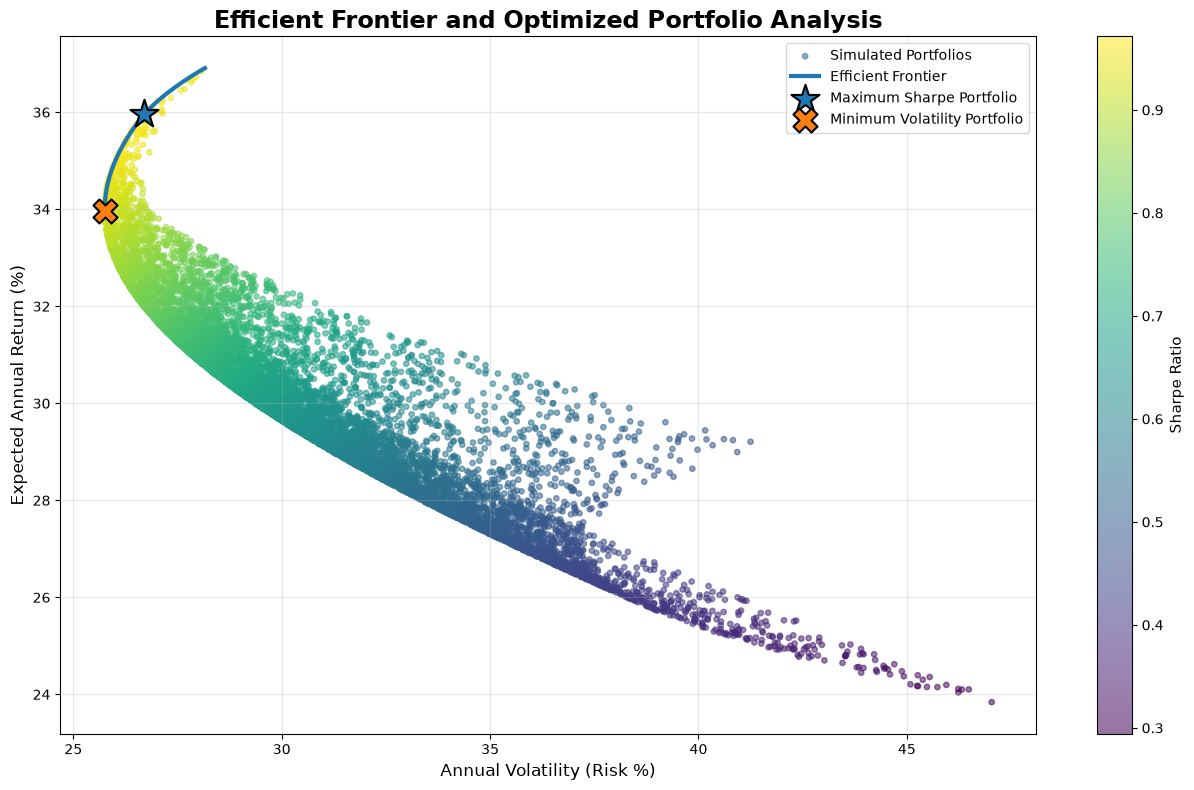

In [29]:
# ============================================================
# EFFICIENT FRONTIER AND PORTFOLIO SIMULATION
# ============================================================

# ------------------------------------------------------------
# 1. CALCULATE REQUIRED ANNUAL DATA
# ------------------------------------------------------------

# Annual expected returns
annual_returns_ef = daily_returns.mean() * 252

# Annual covariance matrix
annual_cov_matrix_ef = daily_returns.cov() * 252

# Number of selected stocks
number_of_assets = len(daily_returns.columns)


# ------------------------------------------------------------
# 2. GENERATE 10,000 RANDOM PORTFOLIOS
# ------------------------------------------------------------

number_of_portfolios = 10000

# Keep random results the same after every run
np.random.seed(42)

# Empty lists to store portfolio results
simulation_returns = []
simulation_volatilities = []
simulation_sharpe_ratios = []


for portfolio in range(number_of_portfolios):

    # Generate random stock weights
    weights = np.random.random(
        number_of_assets
    )

    # Make total allocation equal to 100%
    weights = weights / weights.sum()

    # Calculate expected annual portfolio return
    portfolio_return = np.dot(
        weights,
        annual_returns_ef
    )

    # Calculate annual portfolio volatility
    portfolio_volatility = np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_cov_matrix_ef,
                weights
            )
        )
    )

    # Calculate Sharpe Ratio
    portfolio_sharpe = (
        portfolio_return - risk_free_rate
    ) / portfolio_volatility

    # Store results
    simulation_returns.append(
        portfolio_return
    )

    simulation_volatilities.append(
        portfolio_volatility
    )

    simulation_sharpe_ratios.append(
        portfolio_sharpe
    )


# Convert lists into NumPy arrays
simulation_returns = np.array(
    simulation_returns
)

simulation_volatilities = np.array(
    simulation_volatilities
)

simulation_sharpe_ratios = np.array(
    simulation_sharpe_ratios
)


# ------------------------------------------------------------
# 3. CREATE THE EXACT EFFICIENT FRONTIER
# ------------------------------------------------------------

# Portfolio volatility function
def calculate_frontier_volatility(weights):

    return np.sqrt(
        np.dot(
            weights.T,
            np.dot(
                annual_cov_matrix_ef,
                weights
            )
        )
    )


# Total portfolio allocation must equal 100%
frontier_constraints = (
    {
        "type": "eq",
        "fun": lambda weights:
        np.sum(weights) - 1
    }
)


# No short selling:
# Each stock weight remains between 0% and 100%
frontier_bounds = tuple(
    (0, 1)
    for asset in range(number_of_assets)
)


# Equal weights used as starting values
initial_weights = np.array(
    [1 / number_of_assets] *
    number_of_assets
)


# Generate target returns
target_returns = np.linspace(
    min_vol_return,
    annual_returns_ef.max(),
    100
)


# Empty lists for Efficient Frontier
efficient_frontier_returns = []

efficient_frontier_volatilities = []


# Find minimum-risk portfolio
# for every target return
for target_return in target_returns:

    target_return_constraint = (
        {
            "type": "eq",
            "fun": lambda weights,
            target_return=target_return:
            np.dot(
                weights,
                annual_returns_ef
            ) - target_return
        }
    )

    optimization_result = minimize(
        calculate_frontier_volatility,
        initial_weights,
        method="SLSQP",
        bounds=frontier_bounds,
        constraints=(
            frontier_constraints,
            target_return_constraint
        )
    )

    # Store only successful results
    if optimization_result.success:

        efficient_frontier_returns.append(
            target_return
        )

        efficient_frontier_volatilities.append(
            optimization_result.fun
        )


# Convert Efficient Frontier results
# into NumPy arrays
efficient_frontier_returns = np.array(
    efficient_frontier_returns
)

efficient_frontier_volatilities = np.array(
    efficient_frontier_volatilities
)


# ------------------------------------------------------------
# 4. CREATE COMPLETE EFFICIENT FRONTIER GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(13, 8)
)


# Plot 10,000 simulated portfolios
portfolio_scatter = plt.scatter(
    simulation_volatilities * 100,
    simulation_returns * 100,
    c=simulation_sharpe_ratios,
    cmap="viridis",
    alpha=0.55,
    s=15,
    label="Simulated Portfolios"
)


# Add Sharpe Ratio color bar
color_bar = plt.colorbar(
    portfolio_scatter
)

color_bar.set_label(
    "Sharpe Ratio",
    fontsize=11
)


# Plot exact Efficient Frontier line
plt.plot(
    efficient_frontier_volatilities * 100,
    efficient_frontier_returns * 100,
    linewidth=3,
    label="Efficient Frontier"
)


# Highlight Maximum Sharpe Portfolio
plt.scatter(
    max_sharpe_volatility * 100,
    max_sharpe_return * 100,
    marker="*",
    s=450,
    edgecolors="black",
    linewidths=1.5,
    label="Maximum Sharpe Portfolio",
    zorder=5
)


# Highlight Minimum Volatility Portfolio
plt.scatter(
    min_volatility * 100,
    min_vol_return * 100,
    marker="X",
    s=300,
    edgecolors="black",
    linewidths=1.5,
    label="Minimum Volatility Portfolio",
    zorder=5
)


# ------------------------------------------------------------
# 5. GRAPH FORMATTING
# ------------------------------------------------------------

plt.title(
    "Efficient Frontier and Optimized Portfolio Analysis",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Annual Volatility (Risk %)",
    fontsize=12
)

plt.ylabel(
    "Expected Annual Return (%)",
    fontsize=12
)

plt.legend(
    fontsize=10
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 15. Correlation Heatmap and Diversification Analysis

This section visualizes the correlation between the daily returns of user-selected stocks.

Correlation values range from -1 to +1:

- **+1:** Stocks tend to move strongly in the same direction.
- **0:** Stocks have little or no linear relationship.
- **-1:** Stocks tend to move in opposite directions.

Lower correlation among selected stocks may improve diversification and help reduce overall portfolio risk.

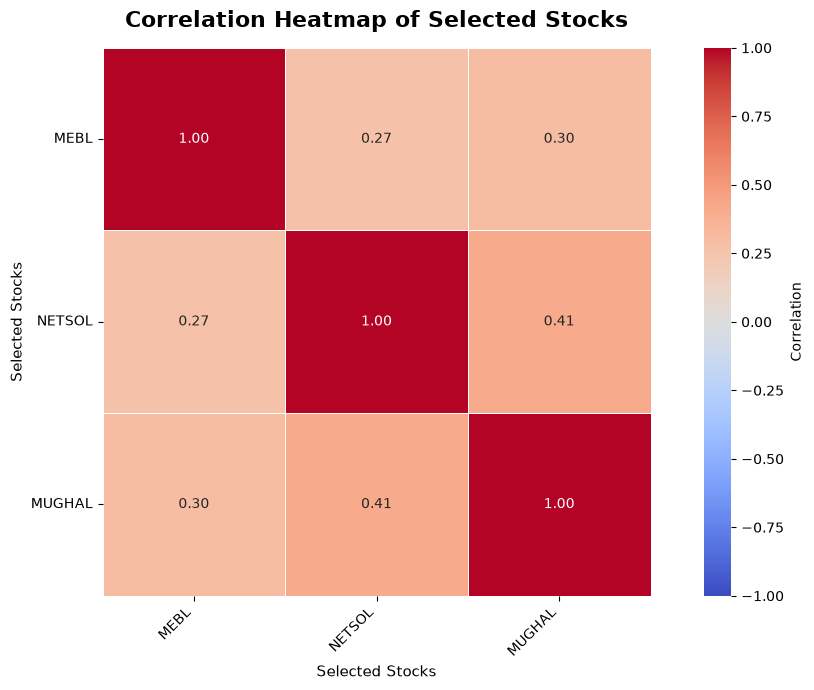

In [30]:
# ============================================================
# CORRELATION HEATMAP AND DIVERSIFICATION ANALYSIS
# ============================================================

# Calculate correlation between selected stocks
correlation_matrix = daily_returns.corr()


# Create the heatmap
plt.figure(figsize=(11, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={
        "label": "Correlation"
    }
)


# Add graph title
plt.title(
    "Correlation Heatmap of Selected Stocks",
    fontsize=16,
    fontweight="bold",
    pad=15
)


# Add axis labels
plt.xlabel(
    "Selected Stocks",
    fontsize=11
)

plt.ylabel(
    "Selected Stocks",
    fontsize=11
)


# Rotate stock names for readability
plt.xticks(
    rotation=45,
    ha="right"
)

plt.yticks(
    rotation=0
)


# Adjust graph spacing
plt.tight_layout()


# Display heatmap
plt.show()

## 17. Maximum Drawdown Analysis

This section measures the largest historical decline from a previous peak to the lowest point for:

- Individual selected stocks
- Maximum Sharpe Ratio Portfolio
- Minimum Volatility Portfolio

A smaller negative drawdown indicates a relatively smaller historical decline, while a larger negative drawdown indicates a more severe historical loss.

> **Note:** Maximum Drawdown is based on historical performance and does not predict future losses.

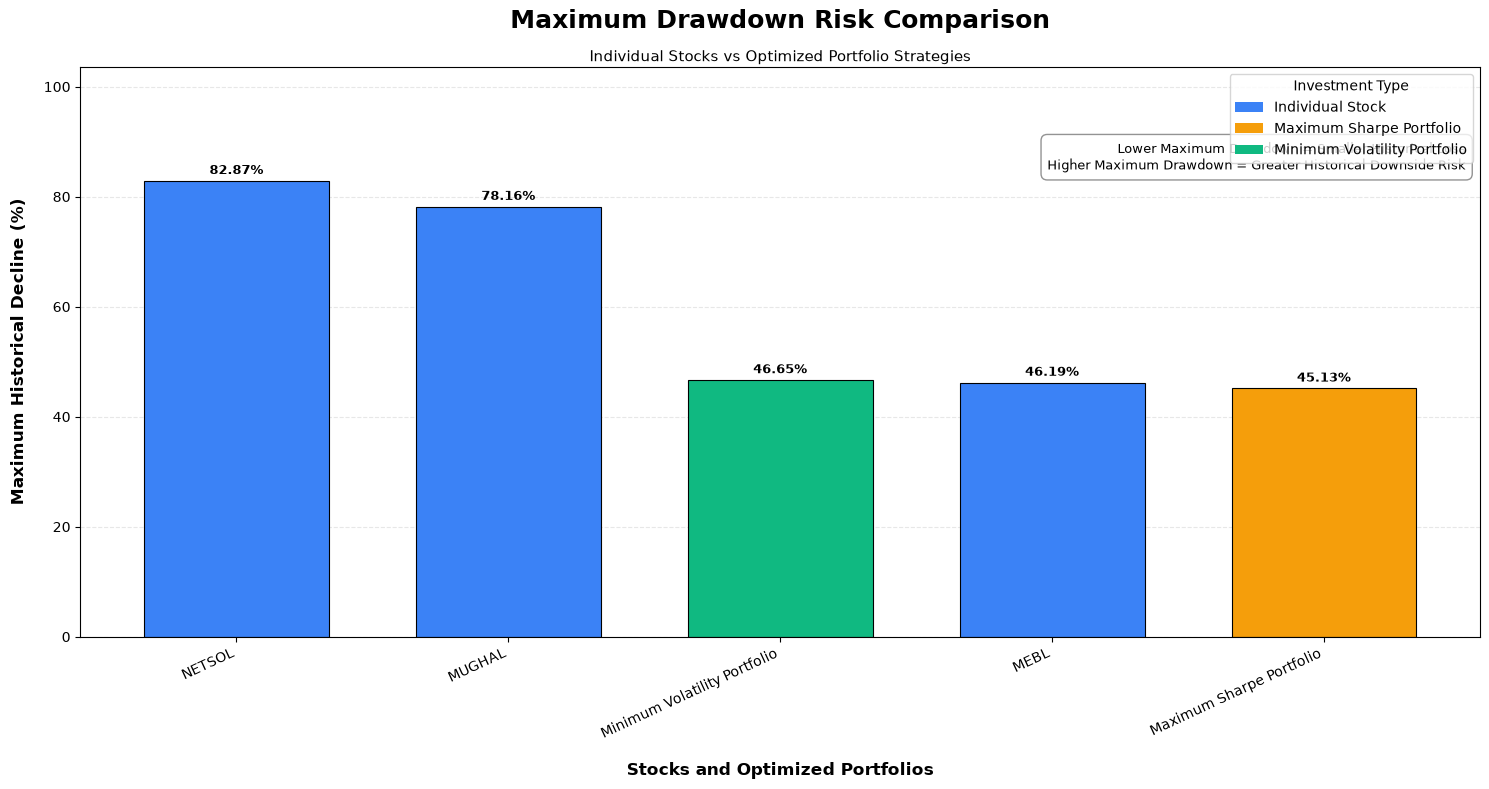


Maximum Drawdown Comparison Table:



,Investment,Maximum Drawdown,Investment Type
1,NETSOL,82.87%,Individual Stock
2,MUGHAL,78.16%,Individual Stock
3,Minimum Volatility Portfolio,46.65%,Minimum Volatility Portfolio
4,MEBL,46.19%,Individual Stock
5,Maximum Sharpe Portfolio,45.13%,Maximum Sharpe Portfolio


In [31]:
# ============================================================
# MAXIMUM DRAWDOWN ANALYSIS
# Individual Stocks vs Optimized Portfolios
# Graph + Comparison Table
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display
from matplotlib.patches import Patch

# Use the daily stock returns calculated earlier
returns = daily_returns.copy()

# ------------------------------------------------------------
# 1. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

# Check stock return data
if "returns" not in globals():

    raise NameError(
        "The 'returns' variable was not found. "
        "Please run the stock returns calculation section first."
    )


# Check Maximum Sharpe Portfolio weights
if "max_sharpe_weights" not in globals():

    raise NameError(
        "The 'max_sharpe_weights' variable was not found. "
        "Please run the portfolio optimization section first."
    )


# Check Minimum Volatility Portfolio weights
if "min_vol_weights" not in globals():

    raise NameError(
        "The 'min_vol_weights' variable was not found. "
        "Please run the portfolio optimization section first."
    )


# ------------------------------------------------------------
# 2. CLEAN STOCK RETURN DATA
# ------------------------------------------------------------

clean_returns = returns.copy()


# Convert all stock returns into numeric values
clean_returns = clean_returns.apply(
    pd.to_numeric,
    errors="coerce"
)


# Remove rows containing missing values
clean_returns = clean_returns.dropna()


# Stop if no valid return data remains
if clean_returns.empty:

    raise ValueError(
        "No valid stock-return observations are available."
    )


# ------------------------------------------------------------
# 3. PREPARE PORTFOLIO WEIGHTS
# ------------------------------------------------------------

# Convert Maximum Sharpe weights into array
maximum_sharpe_weights = np.asarray(
    max_sharpe_weights,
    dtype=float
).flatten()


# Convert Minimum Volatility weights into array
minimum_volatility_weights = np.asarray(
    min_vol_weights,
    dtype=float
).flatten()


# Check that weights match number of stocks
if len(maximum_sharpe_weights) != clean_returns.shape[1]:

    raise ValueError(
        "Maximum Sharpe weights do not match "
        "the number of stocks."
    )


if len(minimum_volatility_weights) != clean_returns.shape[1]:

    raise ValueError(
        "Minimum Volatility weights do not match "
        "the number of stocks."
    )


# ------------------------------------------------------------
# 4. CALCULATE PORTFOLIO DAILY RETURNS
# ------------------------------------------------------------

maximum_sharpe_returns = pd.Series(

    clean_returns.to_numpy()
    @ maximum_sharpe_weights,

    index=clean_returns.index,

    name="Maximum Sharpe Portfolio"
)


minimum_volatility_returns = pd.Series(

    clean_returns.to_numpy()
    @ minimum_volatility_weights,

    index=clean_returns.index,

    name="Minimum Volatility Portfolio"
)


# ------------------------------------------------------------
# 5. MAXIMUM DRAWDOWN FUNCTION
# ------------------------------------------------------------

def calculate_maximum_drawdown(return_series):

    # Remove missing values
    return_series = (
        pd.to_numeric(
            return_series,
            errors="coerce"
        )
        .dropna()
    )


    # Calculate cumulative investment growth
    cumulative_growth = (
        1 + return_series
    ).cumprod()


    # Calculate previous highest value
    running_peak = (
        cumulative_growth
        .cummax()
    )


    # Calculate percentage decline
    drawdown_series = (

        cumulative_growth
        / running_peak

    ) - 1


    # Return maximum historical loss
    return float(
        drawdown_series.min()
    )


# ------------------------------------------------------------
# 6. CALCULATE INDIVIDUAL STOCK DRAWDOWNS
# ------------------------------------------------------------

drawdown_results = []


for stock in clean_returns.columns:

    stock_drawdown = (
        calculate_maximum_drawdown(
            clean_returns[stock]
        )
    )


    drawdown_results.append(

        {
            "Investment": str(stock),

            "Maximum Drawdown (%)":
                abs(stock_drawdown) * 100,

            "Investment Type":
                "Individual Stock"
        }

    )


# ------------------------------------------------------------
# 7. ADD MAXIMUM SHARPE PORTFOLIO
# ------------------------------------------------------------

maximum_sharpe_drawdown = (

    calculate_maximum_drawdown(
        maximum_sharpe_returns
    )

)


drawdown_results.append(

    {
        "Investment":
            "Maximum Sharpe Portfolio",

        "Maximum Drawdown (%)":
            abs(maximum_sharpe_drawdown) * 100,

        "Investment Type":
            "Maximum Sharpe Portfolio"
    }

)


# ------------------------------------------------------------
# 8. ADD MINIMUM VOLATILITY PORTFOLIO
# ------------------------------------------------------------

minimum_volatility_drawdown = (

    calculate_maximum_drawdown(
        minimum_volatility_returns
    )

)


drawdown_results.append(

    {
        "Investment":
            "Minimum Volatility Portfolio",

        "Maximum Drawdown (%)":
            abs(minimum_volatility_drawdown) * 100,

        "Investment Type":
            "Minimum Volatility Portfolio"
    }

)


# ------------------------------------------------------------
# 9. CREATE FINAL DRAWDOWN TABLE
# ------------------------------------------------------------

drawdown_comparison = pd.DataFrame(
    drawdown_results
)


# Remove invalid values
drawdown_comparison[

    "Maximum Drawdown (%)"

] = pd.to_numeric(

    drawdown_comparison[
        "Maximum Drawdown (%)"
    ],

    errors="coerce"

)


drawdown_comparison = (

    drawdown_comparison

    .replace(
        [np.inf, -np.inf],
        np.nan
    )

    .dropna(
        subset=[
            "Maximum Drawdown (%)"
        ]
    )

)


# Sort from highest loss to lowest loss
drawdown_comparison = (

    drawdown_comparison

    .sort_values(

        by="Maximum Drawdown (%)",

        ascending=False

    )

    .reset_index(
        drop=True
    )

)


# ------------------------------------------------------------
# 10. ASSIGN PROFESSIONAL COLORS
# ------------------------------------------------------------

bar_colors = []


for investment_type in (

    drawdown_comparison[
        "Investment Type"
    ]

):

    if (
        investment_type
        == "Maximum Sharpe Portfolio"
    ):

        bar_colors.append(
            "#F59E0B"
        )


    elif (
        investment_type
        == "Minimum Volatility Portfolio"
    ):

        bar_colors.append(
            "#10B981"
        )


    else:

        bar_colors.append(
            "#3B82F6"
        )


# ------------------------------------------------------------
# 11. CREATE MAXIMUM DRAWDOWN GRAPH
# ------------------------------------------------------------

figure, axis = plt.subplots(

    figsize=(15, 8)

)


bars = axis.bar(

    drawdown_comparison[
        "Investment"
    ],

    drawdown_comparison[
        "Maximum Drawdown (%)"
    ],

    color=bar_colors,

    edgecolor="black",

    linewidth=0.8,

    width=0.68

)


# ------------------------------------------------------------
# 12. ADD VALUES ABOVE BARS
# ------------------------------------------------------------

for bar, value in zip(

    bars,

    drawdown_comparison[
        "Maximum Drawdown (%)"
    ]

):

    axis.text(

        bar.get_x()
        + bar.get_width() / 2,

        bar.get_height()
        + 0.7,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=9,

        fontweight="bold"

    )


# ------------------------------------------------------------
# 13. GRAPH TITLE AND LABELS
# ------------------------------------------------------------

axis.set_title(

    "Maximum Drawdown Risk Comparison",

    fontsize=18,

    fontweight="bold",

    pad=28

)


axis.text(

    0.5,

    1.01,

    "Individual Stocks vs Optimized Portfolio Strategies",

    transform=axis.transAxes,

    ha="center",

    fontsize=11

)


axis.set_xlabel(

    "Stocks and Optimized Portfolios",

    fontsize=12,

    fontweight="bold",

    labelpad=15

)


axis.set_ylabel(

    "Maximum Historical Decline (%)",

    fontsize=12,

    fontweight="bold",

    labelpad=12

)


# ------------------------------------------------------------
# 14. SET SAFE GRAPH LIMIT
# ------------------------------------------------------------

maximum_value = (

    drawdown_comparison[

        "Maximum Drawdown (%)"

    ].max()

)


if (

    pd.isna(maximum_value)

    or not np.isfinite(
        maximum_value
    )

    or maximum_value <= 0

):

    maximum_value = 10


axis.set_ylim(

    0,

    maximum_value * 1.25

)


# ------------------------------------------------------------
# 15. ADD GRID
# ------------------------------------------------------------

axis.grid(

    axis="y",

    linestyle="--",

    alpha=0.30

)


axis.set_axisbelow(
    True
)


# ------------------------------------------------------------
# 16. ROTATE INVESTMENT NAMES
# ------------------------------------------------------------

plt.xticks(

    rotation=25,

    ha="right",

    fontsize=10

)


# ------------------------------------------------------------
# 17. CREATE GRAPH LEGEND
# ------------------------------------------------------------

legend_items = [

    Patch(

        facecolor="#3B82F6",

        label="Individual Stock"

    ),


    Patch(

        facecolor="#F59E0B",

        label="Maximum Sharpe Portfolio"

    ),


    Patch(

        facecolor="#10B981",

        label="Minimum Volatility Portfolio"

    )

]


axis.legend(

    handles=legend_items,

    title="Investment Type",

    loc="upper right",

    frameon=True

)


# ------------------------------------------------------------
# 18. ADD INTERPRETATION BOX
# ------------------------------------------------------------

interpretation_text = (

    "Lower Maximum Drawdown = Smaller Historical Loss\n"

    "Higher Maximum Drawdown = Greater Historical Downside Risk"

)


axis.text(

    0.99,

    0.82,

    interpretation_text,

    transform=axis.transAxes,

    ha="right",

    fontsize=9,

    bbox=dict(

        boxstyle="round,pad=0.5",

        facecolor="white",

        edgecolor="gray",

        alpha=0.85

    )

)


# ------------------------------------------------------------
# 19. DISPLAY GRAPH
# ------------------------------------------------------------

plt.tight_layout()

plt.show()


# ------------------------------------------------------------
# 20. CREATE COMPARISON TABLE
# ------------------------------------------------------------

drawdown_display_table = (

    drawdown_comparison[

        [
            "Investment",

            "Maximum Drawdown (%)",

            "Investment Type"
        ]

    ]

    .copy()

)


# Rename percentage column
drawdown_display_table = (

    drawdown_display_table

    .rename(

        columns={

            "Maximum Drawdown (%)":
            "Maximum Drawdown"

        }

    )

)


# Format values as percentages
drawdown_display_table[

    "Maximum Drawdown"

] = (

    drawdown_display_table[

        "Maximum Drawdown"

    ]

    .map(

        lambda value:

        f"{value:.2f}%"

    )

)


# Start row numbers from 1
drawdown_display_table.index = (

    range(

        1,

        len(
            drawdown_display_table
        ) + 1

    )

)


# ------------------------------------------------------------
# 21. DISPLAY FINAL TABLE
# ------------------------------------------------------------

print(

    "\nMaximum Drawdown Comparison Table:\n"

)


display(

    drawdown_display_table

)

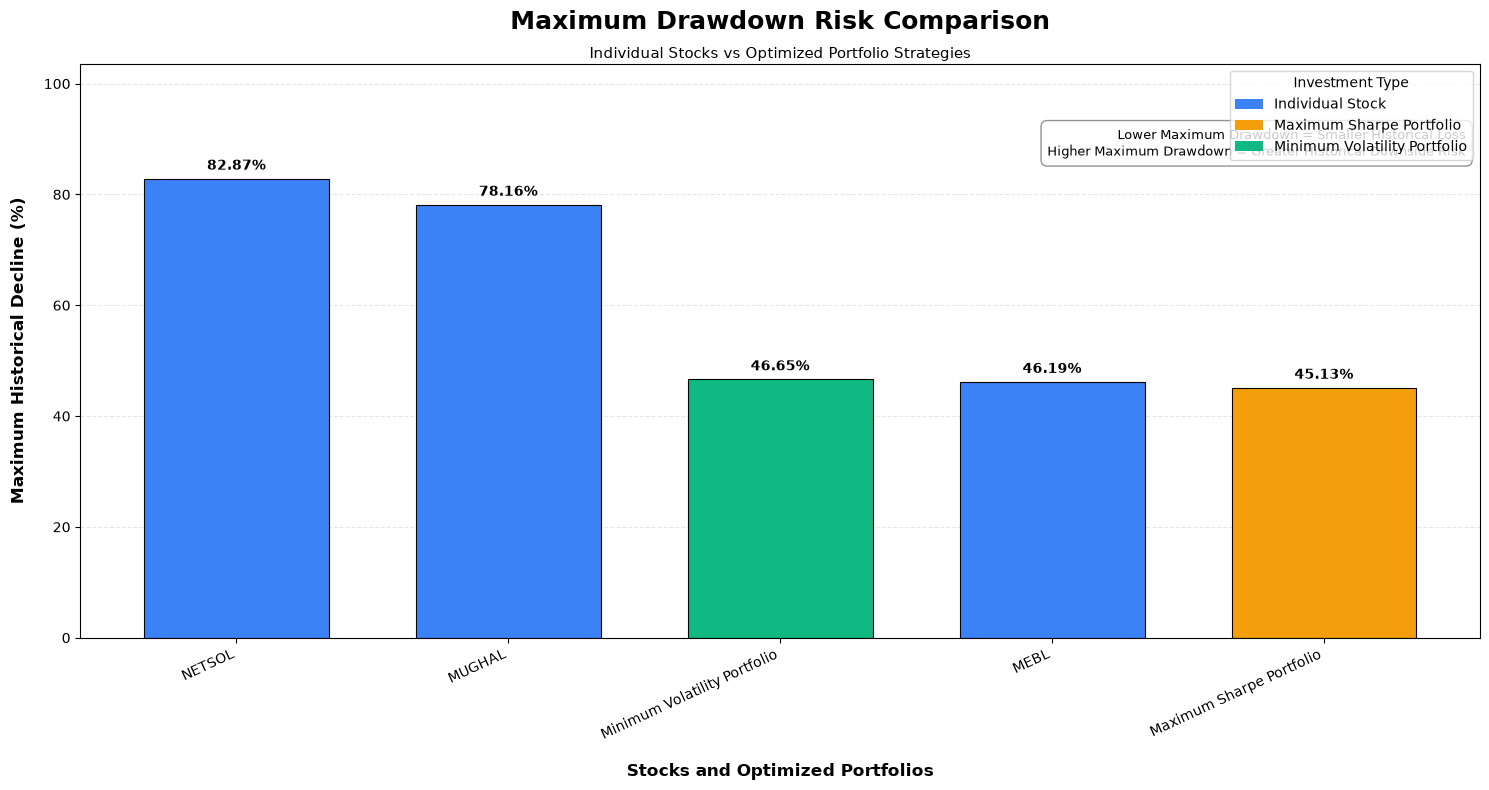


Maximum Drawdown Comparison Table:


,Investment,Maximum Drawdown,Investment Type
1,NETSOL,82.87%,Individual Stock
2,MUGHAL,78.16%,Individual Stock
3,Minimum Volatility Portfolio,46.65%,Minimum Volatility Portfolio
4,MEBL,46.19%,Individual Stock
5,Maximum Sharpe Portfolio,45.13%,Maximum Sharpe Portfolio


In [32]:
# ============================================================
# MAXIMUM DRAWDOWN COMPARISON GRAPH
# Individual Stocks vs Optimized Portfolios
# ============================================================

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. COPY THE ORIGINAL DRAWDOWN TABLE
# ------------------------------------------------------------

drawdown_bar_data = drawdown_comparison.copy()


# ------------------------------------------------------------
# 2. FIND REQUIRED COLUMNS AUTOMATICALLY
# ------------------------------------------------------------

# Find investment/name column
name_column = None

for column in drawdown_bar_data.columns:

    if str(column).strip().lower() in [
        "investment",
        "stock",
        "portfolio",
        "portfolio strategy",
        "asset"
    ]:

        name_column = column
        break


# If investment names are stored in index
if name_column is None:

    drawdown_bar_data = drawdown_bar_data.reset_index()

    name_column = drawdown_bar_data.columns[0]


# Find Maximum Drawdown column
drawdown_column = None

for column in drawdown_bar_data.columns:

    if "drawdown" in str(column).lower():

        drawdown_column = column
        break


# Stop code if drawdown column is unavailable
if drawdown_column is None:

    raise ValueError(
        "Maximum Drawdown column was not found "
        "inside drawdown_comparison."
    )


# ------------------------------------------------------------
# 3. CLEAN MAXIMUM DRAWDOWN VALUES
# ------------------------------------------------------------

# Convert column into normal text first
clean_drawdown = (
    drawdown_bar_data[drawdown_column]
    .astype(str)
    .str.strip()
    .str.replace("%", "", regex=False)
    .str.replace(",", "", regex=False)
)


# Convert cleaned values into numbers
clean_drawdown = pd.to_numeric(
    clean_drawdown,
    errors="coerce"
)


# Remove rows where Maximum Drawdown is missing
valid_rows = clean_drawdown.notna()

drawdown_bar_data = (
    drawdown_bar_data
    .loc[valid_rows]
    .copy()
)

clean_drawdown = (
    clean_drawdown
    .loc[valid_rows]
    .astype(float)
)


# ------------------------------------------------------------
# 4. CONVERT VALUES INTO POSITIVE LOSS PERCENTAGES
# ------------------------------------------------------------

# If values are decimals:
# -0.46 becomes 46%

# If values are already percentages:
# -46 remains 46%

if clean_drawdown.abs().max() <= 1:

    maximum_drawdown_percentage = (
        clean_drawdown.abs() * 100
    )

else:

    maximum_drawdown_percentage = (
        clean_drawdown.abs()
    )


# Save clean percentages
drawdown_bar_data["Maximum Drawdown (%)"] = (
    maximum_drawdown_percentage.to_numpy()
)


# Convert investment names into normal text
drawdown_bar_data[name_column] = (
    drawdown_bar_data[name_column]
    .astype(str)
)


# ------------------------------------------------------------
# 5. IDENTIFY INVESTMENT TYPES
# ------------------------------------------------------------

def identify_investment_type(investment_name):

    investment_name = investment_name.lower()

    if "maximum sharpe" in investment_name:

        return "Maximum Sharpe Portfolio"

    elif "minimum volatility" in investment_name:

        return "Minimum Volatility Portfolio"

    else:

        return "Individual Stock"


drawdown_bar_data["Investment Type"] = (
    drawdown_bar_data[name_column]
    .apply(identify_investment_type)
)


# ------------------------------------------------------------
# 6. SORT FROM HIGHEST LOSS TO LOWEST LOSS
# ------------------------------------------------------------

drawdown_bar_data = (
    drawdown_bar_data
    .sort_values(
        by="Maximum Drawdown (%)",
        ascending=False
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. ASSIGN COLORS
# ------------------------------------------------------------

bar_colors = []

for investment_type in drawdown_bar_data["Investment Type"]:

    if investment_type == "Maximum Sharpe Portfolio":

        bar_colors.append("#F59E0B")

    elif investment_type == "Minimum Volatility Portfolio":

        bar_colors.append("#10B981")

    else:

        bar_colors.append("#3B82F6")


# ------------------------------------------------------------
# 8. CREATE ENHANCED GRAPH
# ------------------------------------------------------------

figure, axis = plt.subplots(
    figsize=(15, 8)
)


bars = axis.bar(
    drawdown_bar_data[name_column],
    drawdown_bar_data["Maximum Drawdown (%)"],
    color=bar_colors,
    edgecolor="black",
    linewidth=0.8,
    width=0.68
)


# ------------------------------------------------------------
# 9. ADD VALUES ABOVE BARS
# ------------------------------------------------------------

for bar, value in zip(
    bars,
    drawdown_bar_data["Maximum Drawdown (%)"]
):

    axis.text(

        bar.get_x() + bar.get_width() / 2,

        bar.get_height() + 1,

        f"{value:.2f}%",

        horizontalalignment="center",

        verticalalignment="bottom",

        fontsize=10,

        fontweight="bold"
    )


# ------------------------------------------------------------
# 10. GRAPH TITLES AND LABELS
# ------------------------------------------------------------

axis.set_title(

    "Maximum Drawdown Risk Comparison",

    fontsize=18,

    fontweight="bold",

    pad=25
)


axis.text(

    0.5,

    1.01,

    "Individual Stocks vs Optimized Portfolio Strategies",

    transform=axis.transAxes,

    horizontalalignment="center",

    fontsize=11
)


axis.set_xlabel(

    "Stocks and Optimized Portfolios",

    fontsize=12,

    fontweight="bold",

    labelpad=15
)


axis.set_ylabel(

    "Maximum Historical Decline (%)",

    fontsize=12,

    fontweight="bold",

    labelpad=12
)


# ------------------------------------------------------------
# 11. ADD SAFE Y-AXIS LIMIT
# ------------------------------------------------------------

maximum_value = float(
    drawdown_bar_data[
        "Maximum Drawdown (%)"
    ].max()
)


# Prevent NaN, infinity or zero-axis errors
if (
    not np.isfinite(maximum_value)
    or maximum_value <= 0
):

    maximum_value = 10


axis.set_ylim(

    0,

    maximum_value * 1.25
)


# ------------------------------------------------------------
# 12. ADD GRAPH GRID
# ------------------------------------------------------------

axis.grid(

    axis="y",

    linestyle="--",

    alpha=0.30
)


axis.set_axisbelow(True)


# ------------------------------------------------------------
# 13. ROTATE INVESTMENT NAMES
# ------------------------------------------------------------

plt.xticks(

    rotation=25,

    horizontalalignment="right",

    fontsize=10
)


# ------------------------------------------------------------
# 14. CREATE CUSTOM LEGEND
# ------------------------------------------------------------

from matplotlib.patches import Patch


legend_items = [

    Patch(
        facecolor="#3B82F6",
        label="Individual Stock"
    ),

    Patch(
        facecolor="#F59E0B",
        label="Maximum Sharpe Portfolio"
    ),

    Patch(
        facecolor="#10B981",
        label="Minimum Volatility Portfolio"
    )
]


axis.legend(

    handles=legend_items,

    title="Investment Type",

    loc="upper right",

    frameon=True
)


# ------------------------------------------------------------
# 15. ADD INTERPRETATION BOX
# ------------------------------------------------------------

interpretation_text = (

    "Lower Maximum Drawdown = Smaller Historical Loss\n"

    "Higher Maximum Drawdown = Greater Historical Downside Risk"

)


axis.text(

    0.99,

    0.84,

    interpretation_text,

    transform=axis.transAxes,

    horizontalalignment="right",

    fontsize=9,

    bbox=dict(

        boxstyle="round,pad=0.5",

        facecolor="white",

        edgecolor="gray",

        alpha=0.85

    )
)


# ------------------------------------------------------------
# 16. ADJUST AND DISPLAY GRAPH
# ------------------------------------------------------------

plt.tight_layout()

plt.show()
# ============================================================
# DISPLAY MAXIMUM DRAWDOWN COMPARISON TABLE
# ============================================================

# Create a separate table for display
drawdown_display_table = drawdown_bar_data[
    [
        name_column,
        "Maximum Drawdown (%)",
        "Investment Type"
    ]
].copy()


# Rename columns professionally
drawdown_display_table.columns = [
    "Investment",
    "Maximum Drawdown",
    "Investment Type"
]


# Format Maximum Drawdown as percentage
drawdown_display_table["Maximum Drawdown"] = (
    drawdown_display_table["Maximum Drawdown"]
    .apply(lambda value: f"{value:.2f}%")
)


# Reset row numbers
drawdown_display_table = (
    drawdown_display_table
    .reset_index(drop=True)
)


# Start index from 1 instead of 0
drawdown_display_table.index = (
    drawdown_display_table.index + 1
)


# Display heading
print(
    "\nMaximum Drawdown Comparison Table:"
)


# Display table below the graph
display(
    drawdown_display_table
)

## 19. Historical Portfolio Backtesting

This section evaluates the historical out-of-sample performance of both optimized portfolio strategies.

The available historical dataset is divided into two periods:

- **Training Period:** Historical data used to estimate expected returns, covariance, and optimal portfolio weights.
- **Testing Period:** Later unseen historical data used to evaluate the performance of the fixed portfolio weights obtained from the training period.

The backtesting analysis compares:

- Maximum Sharpe Ratio Portfolio
- Minimum Volatility Portfolio
- Growth of the user's initial investment
- Final Backtested Portfolio Value
- Total Return
- Annualized Return

The portfolio weights are calculated using only the training-period data and remain fixed throughout the testing period.

> **Important:** Historical backtesting evaluates past performance and does not guarantee future investment results.

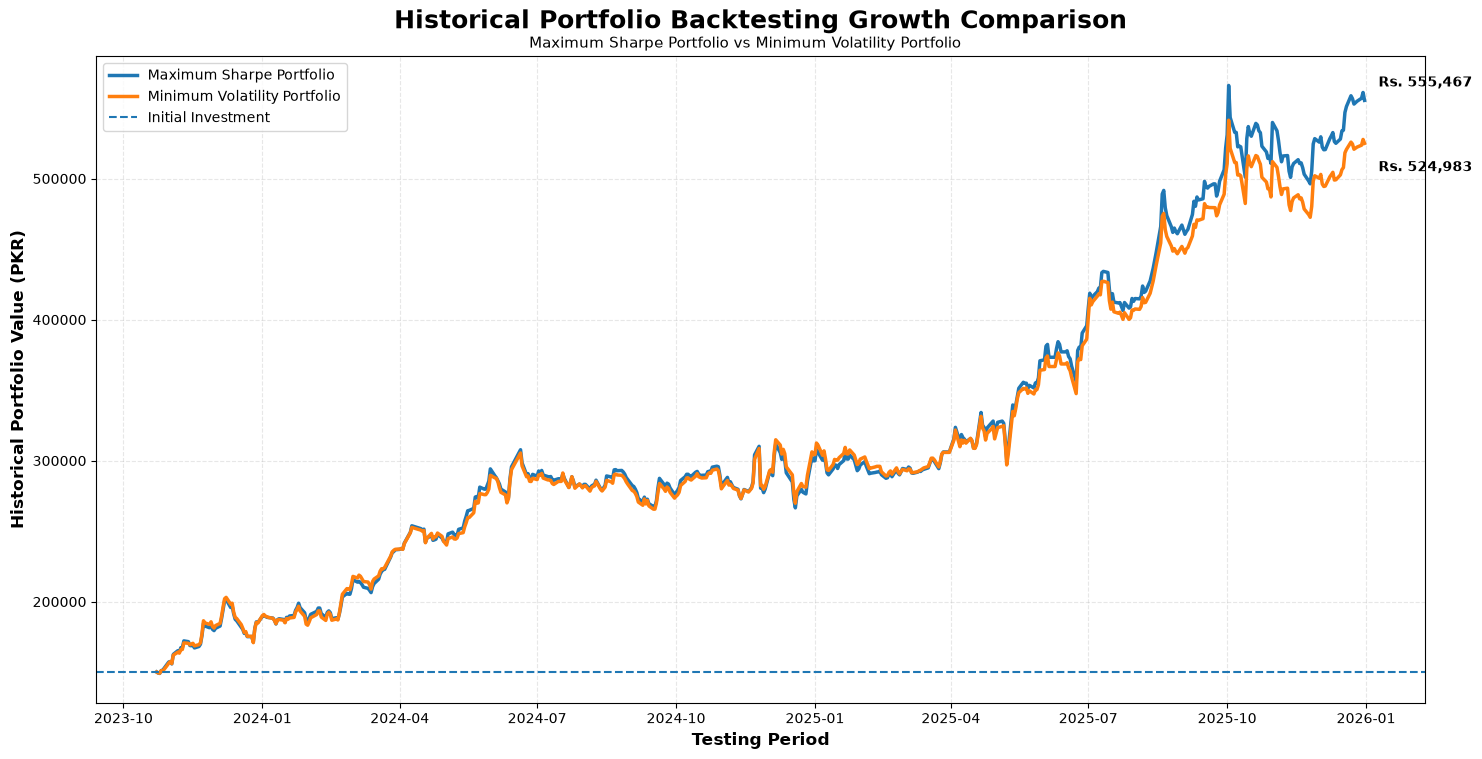


Historical Portfolio Backtesting Results:



,Portfolio Strategy,Initial Investment,Final Backtested Value,Total Return,Annualized Return,Training Period,Testing Period
1,Maximum Sharpe Portfolio,"Rs. 150,000.00","Rs. 555,466.65",270.31%,81.20%,2015–2023,2023–2025
2,Minimum Volatility Portfolio,"Rs. 150,000.00","Rs. 524,983.22",249.99%,76.62%,2015–2023,2023–2025


In [33]:
# ============================================================
# HISTORICAL PORTFOLIO BACKTESTING
# Maximum Sharpe vs Minimum Volatility Portfolio
# Graph + Detailed Comparison Table
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from IPython.display import display


# ------------------------------------------------------------
# 1. PREPARE DAILY STOCK RETURNS
# ------------------------------------------------------------

# Automatically use the available daily-return DataFrame
if "daily_returns" in globals():

    backtest_returns = daily_returns.copy()

elif "returns" in globals():

    backtest_returns = returns.copy()

else:

    raise NameError(
        "Daily stock returns were not found. "
        "Run the previous return-calculation cells first."
    )


# Keep only numeric stock-return columns
backtest_returns = (
    backtest_returns
    .select_dtypes(include=[np.number])
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)


# Convert index into dates if required
if not isinstance(
    backtest_returns.index,
    pd.DatetimeIndex
):

    backtest_returns.index = pd.to_datetime(
        backtest_returns.index
    )


# Sort observations by date
backtest_returns = (
    backtest_returns
    .sort_index()
)


# Stop if insufficient data is available
if len(backtest_returns) < 100:

    raise ValueError(
        "Insufficient historical observations "
        "are available for backtesting."
    )


# ------------------------------------------------------------
# 2. DIVIDE DATA INTO TRAINING AND TESTING PERIODS
# ------------------------------------------------------------

# First 80% = Training data
# Last 20% = Unseen testing data

split_position = int(
    len(backtest_returns) * 0.80
)


training_returns = (
    backtest_returns
    .iloc[:split_position]
    .copy()
)


testing_returns = (
    backtest_returns
    .iloc[split_position:]
    .copy()
)


# ------------------------------------------------------------
# 3. CALCULATE TRAINING-PERIOD STATISTICS
# ------------------------------------------------------------

# Expected annual returns
training_annual_returns = (
    training_returns.mean() * 252
)


# Annual covariance matrix
training_annual_covariance = (
    training_returns.cov() * 252
)


number_of_assets = len(
    training_returns.columns
)


# ------------------------------------------------------------
# 4. PORTFOLIO CALCULATION FUNCTIONS
# ------------------------------------------------------------

def calculate_portfolio_return(weights):

    return float(
        np.dot(
            weights,
            training_annual_returns
        )
    )


def calculate_portfolio_volatility(weights):

    portfolio_variance = np.dot(

        weights.T,

        np.dot(
            training_annual_covariance,
            weights
        )
    )

    return float(
        np.sqrt(portfolio_variance)
    )


def calculate_negative_sharpe(weights):

    portfolio_return = (
        calculate_portfolio_return(weights)
    )

    portfolio_volatility = (
        calculate_portfolio_volatility(weights)
    )

    if portfolio_volatility == 0:

        return 1e10

    return -(
        (
            portfolio_return
            - risk_free_rate
        )
        /
        portfolio_volatility
    )


# ------------------------------------------------------------
# 5. SET OPTIMIZATION CONDITIONS
# ------------------------------------------------------------

# Use the risk-free rate selected earlier
if "risk_free_rate" not in globals():

    risk_free_rate = 0.0


# All portfolio weights must total 100%
optimization_constraints = (

    {
        "type": "eq",

        "fun": lambda weights:
        np.sum(weights) - 1
    },

)


# No short selling:
# Every weight remains between 0% and 100%

optimization_bounds = tuple(

    (0, 1)

    for asset in range(
        number_of_assets
    )
)


# Equal weights as starting values
starting_weights = np.array(

    [
        1 / number_of_assets
    ]
    * number_of_assets

)


# ------------------------------------------------------------
# 6. OPTIMIZE MAXIMUM SHARPE PORTFOLIO
# ------------------------------------------------------------

maximum_sharpe_result = minimize(

    calculate_negative_sharpe,

    starting_weights,

    method="SLSQP",

    bounds=optimization_bounds,

    constraints=optimization_constraints
)


if not maximum_sharpe_result.success:

    raise ValueError(

        "Maximum Sharpe optimization failed: "

        + maximum_sharpe_result.message

    )


maximum_sharpe_backtest_weights = (
    maximum_sharpe_result.x
)


# ------------------------------------------------------------
# 7. OPTIMIZE MINIMUM VOLATILITY PORTFOLIO
# ------------------------------------------------------------

minimum_volatility_result = minimize(

    calculate_portfolio_volatility,

    starting_weights,

    method="SLSQP",

    bounds=optimization_bounds,

    constraints=optimization_constraints
)


if not minimum_volatility_result.success:

    raise ValueError(

        "Minimum Volatility optimization failed: "

        + minimum_volatility_result.message

    )


minimum_volatility_backtest_weights = (
    minimum_volatility_result.x
)


# ------------------------------------------------------------
# 8. APPLY FIXED WEIGHTS TO UNSEEN TEST DATA
# ------------------------------------------------------------

maximum_sharpe_test_returns = (

    testing_returns

    @ maximum_sharpe_backtest_weights

)


minimum_volatility_test_returns = (

    testing_returns

    @ minimum_volatility_backtest_weights

)


# ------------------------------------------------------------
# 9. CALCULATE PORTFOLIO GROWTH
# ------------------------------------------------------------

# Use the initial investment entered earlier

if "initial_investment" not in globals():

    initial_investment = 150000


# Maximum Sharpe portfolio growth

maximum_sharpe_growth = (

    initial_investment

    * (
        1
        + maximum_sharpe_test_returns
    ).cumprod()

)


# Minimum Volatility portfolio growth

minimum_volatility_growth = (

    initial_investment

    * (
        1
        + minimum_volatility_test_returns
    ).cumprod()

)


# ------------------------------------------------------------
# 10. CALCULATE FINAL VALUES
# ------------------------------------------------------------

maximum_sharpe_final_value = float(

    maximum_sharpe_growth.iloc[-1]

)


minimum_volatility_final_value = float(

    minimum_volatility_growth.iloc[-1]

)


# ------------------------------------------------------------
# 11. CALCULATE TOTAL RETURNS
# ------------------------------------------------------------

maximum_sharpe_total_return = (

    (
        maximum_sharpe_final_value

        / initial_investment

    ) - 1

)


minimum_volatility_total_return = (

    (
        minimum_volatility_final_value

        / initial_investment

    ) - 1

)


# ------------------------------------------------------------
# 12. CALCULATE ANNUALIZED RETURNS
# ------------------------------------------------------------

testing_years = (

    len(testing_returns)

    / 252

)


maximum_sharpe_annualized_return = (

    (
        maximum_sharpe_final_value

        / initial_investment

    )

    ** (
        1 / testing_years
    )

    - 1

)


minimum_volatility_annualized_return = (

    (
        minimum_volatility_final_value

        / initial_investment

    )

    ** (
        1 / testing_years
    )

    - 1

)


# ------------------------------------------------------------
# 13. CREATE HISTORICAL GROWTH GRAPH
# ------------------------------------------------------------

plt.figure(
    figsize=(15, 8)
)


# Maximum Sharpe growth line

plt.plot(

    maximum_sharpe_growth.index,

    maximum_sharpe_growth.values,

    linewidth=2.5,

    label="Maximum Sharpe Portfolio"

)


# Minimum Volatility growth line

plt.plot(

    minimum_volatility_growth.index,

    minimum_volatility_growth.values,

    linewidth=2.5,

    label="Minimum Volatility Portfolio"

)


# Initial investment reference line

plt.axhline(

    y=initial_investment,

    linestyle="--",

    linewidth=1.5,

    label="Initial Investment"

)


# Add graph title

plt.title(

    "Historical Portfolio Backtesting Growth Comparison",

    fontsize=18,

    fontweight="bold",

    pad=20

)


# Add subtitle

plt.suptitle(

    "Maximum Sharpe Portfolio vs Minimum Volatility Portfolio",

    fontsize=11,

    y=0.91

)


# Axis labels

plt.xlabel(

    "Testing Period",

    fontsize=12,

    fontweight="bold"

)


plt.ylabel(

    "Historical Portfolio Value (PKR)",

    fontsize=12,

    fontweight="bold"

)


# Add grid

plt.grid(

    alpha=0.30,

    linestyle="--"

)


# Add legend

plt.legend(

    fontsize=10,

    loc="best"

)


# Add final-value labels

plt.annotate(

    f"Rs. {maximum_sharpe_final_value:,.0f}",

    xy=(

        maximum_sharpe_growth.index[-1],

        maximum_sharpe_final_value

    ),

    xytext=(10, 10),

    textcoords="offset points",

    fontsize=10,

    fontweight="bold"

)


plt.annotate(

    f"Rs. {minimum_volatility_final_value:,.0f}",

    xy=(

        minimum_volatility_growth.index[-1],

        minimum_volatility_final_value

    ),

    xytext=(10, -20),

    textcoords="offset points",

    fontsize=10,

    fontweight="bold"

)


# Adjust graph spacing

plt.tight_layout()


# Display graph

plt.show()


# ------------------------------------------------------------
# 14. CREATE DETAILED BACKTESTING TABLE
# ------------------------------------------------------------

backtesting_summary = pd.DataFrame(

    {

        "Portfolio Strategy": [

            "Maximum Sharpe Portfolio",

            "Minimum Volatility Portfolio"

        ],


        "Initial Investment": [

            initial_investment,

            initial_investment

        ],


        "Final Backtested Value": [

            maximum_sharpe_final_value,

            minimum_volatility_final_value

        ],


        "Total Return": [

            maximum_sharpe_total_return,

            minimum_volatility_total_return

        ],


        "Annualized Return": [

            maximum_sharpe_annualized_return,

            minimum_volatility_annualized_return

        ],


        "Training Period": [

            (
                f"{training_returns.index.min().year}"
                f"–"
                f"{training_returns.index.max().year}"
            ),

            (
                f"{training_returns.index.min().year}"
                f"–"
                f"{training_returns.index.max().year}"
            )

        ],


        "Testing Period": [

            (
                f"{testing_returns.index.min().year}"
                f"–"
                f"{testing_returns.index.max().year}"
            ),

            (
                f"{testing_returns.index.min().year}"
                f"–"
                f"{testing_returns.index.max().year}"
            )

        ]

    }

)


# ------------------------------------------------------------
# 15. FORMAT TABLE VALUES
# ------------------------------------------------------------

backtesting_summary[
    "Initial Investment"
] = (

    backtesting_summary[
        "Initial Investment"
    ]

    .apply(

        lambda value:

        f"Rs. {value:,.2f}"

    )

)


backtesting_summary[
    "Final Backtested Value"
] = (

    backtesting_summary[
        "Final Backtested Value"
    ]

    .apply(

        lambda value:

        f"Rs. {value:,.2f}"

    )

)


backtesting_summary[
    "Total Return"
] = (

    backtesting_summary[
        "Total Return"
    ]

    .apply(

        lambda value:

        f"{value:.2%}"

    )

)


backtesting_summary[
    "Annualized Return"
] = (

    backtesting_summary[
        "Annualized Return"
    ]

    .apply(

        lambda value:

        f"{value:.2%}"

    )

)


# Start table index from 1

backtesting_summary.index = (

    backtesting_summary.index + 1

)


# ------------------------------------------------------------
# 16. DISPLAY TABLE BELOW GRAPH
# ------------------------------------------------------------

print(
    "\nHistorical Portfolio Backtesting Results:\n"
)


display(
    backtesting_summary
)

## 20. Complete Optimized Portfolio Performance Summary

This section consolidates the key performance and risk metrics of both optimized portfolio strategies into a single comparison dashboard.

The summary compares:

- Expected Annual Return
- Annual Volatility
- Sharpe Ratio
- Portfolio Beta
- Maximum Drawdown
- Hypothetical Investment Values
- Historical Backtesting Performance

This consolidated analysis helps investors compare the risk-return characteristics of the Maximum Sharpe and Minimum Volatility portfolio strategies.

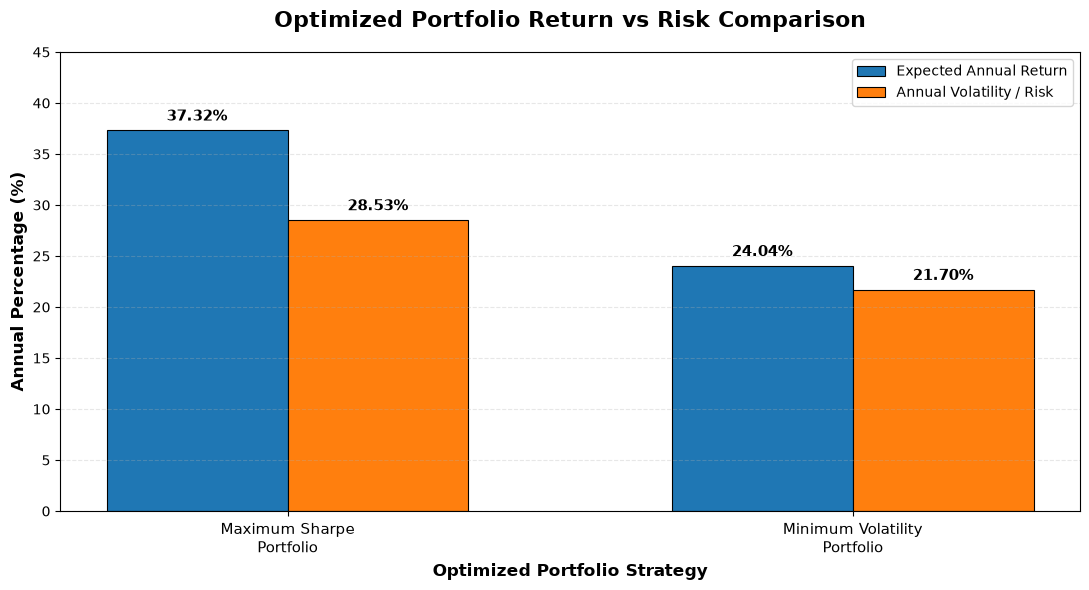


Complete Optimized Portfolio Performance Summary:



,Portfolio Strategy,Expected Annual Return,Annual Volatility,Sharpe Ratio,Portfolio Beta,Maximum Drawdown,Hypothetical Value After 1 Year,Hypothetical Value After 5 Years
0,Maximum Sharpe Portfolio,37.32%,28.53%,0.96,0.483,-44.95%,"Rs. 205,982.63","Rs. 732,466.00"
1,Minimum Volatility Portfolio,24.04%,21.70%,0.65,0.332,-39.15%,"Rs. 186,062.31","Rs. 440,480.00"


In [34]:
# ============================================================
# OPTIMIZED PORTFOLIO PERFORMANCE COMPARISON
# Return vs Risk Graph + Complete Summary Table
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


# ------------------------------------------------------------
# 1. FINAL PORTFOLIO VALUES
# ------------------------------------------------------------

portfolio_data = pd.DataFrame({

    "Portfolio Strategy": [
        "Maximum Sharpe Portfolio",
        "Minimum Volatility Portfolio"
    ],

    "Expected Annual Return": [
        37.32,
        24.04
    ],

    "Annual Volatility": [
        28.53,
        21.70
    ],

    "Sharpe Ratio": [
        0.96,
        0.65
    ],

    "Portfolio Beta": [
        0.483,
        0.332
    ],

    "Maximum Drawdown": [
        -44.95,
        -39.15
    ],

    "Hypothetical Value After 1 Year": [
        205982.63,
        186062.31
    ],

    "Hypothetical Value After 5 Years": [
        732466.00,
        440480.00
    ]

})


# ------------------------------------------------------------
# 2. DATA FOR GRAPH
# ------------------------------------------------------------

portfolio_names = [
    "Maximum Sharpe\nPortfolio",
    "Minimum Volatility\nPortfolio"
]

returns = portfolio_data[
    "Expected Annual Return"
].to_numpy()

risks = portfolio_data[
    "Annual Volatility"
].to_numpy()


# ------------------------------------------------------------
# 3. CREATE RETURN VS RISK BAR GRAPH
# ------------------------------------------------------------

x = np.arange(
    len(portfolio_names)
)

bar_width = 0.32


fig, ax = plt.subplots(
    figsize=(11, 6)
)


# Expected Return Bars

return_bars = ax.bar(

    x - bar_width / 2,

    returns,

    width=bar_width,

    label="Expected Annual Return",

    edgecolor="black",

    linewidth=0.8
)


# Annual Risk Bars

risk_bars = ax.bar(

    x + bar_width / 2,

    risks,

    width=bar_width,

    label="Annual Volatility / Risk",

    edgecolor="black",

    linewidth=0.8
)


# ------------------------------------------------------------
# 4. ADD VALUES ABOVE BARS
# ------------------------------------------------------------

for bar in return_bars:

    value = bar.get_height()

    ax.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.6,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"
    )


for bar in risk_bars:

    value = bar.get_height()

    ax.text(

        bar.get_x()
        + bar.get_width() / 2,

        value + 0.6,

        f"{value:.2f}%",

        ha="center",

        va="bottom",

        fontsize=11,

        fontweight="bold"
    )


# ------------------------------------------------------------
# 5. FORMAT GRAPH
# ------------------------------------------------------------

ax.set_title(

    "Optimized Portfolio Return vs Risk Comparison",

    fontsize=16,

    fontweight="bold",

    pad=18
)


ax.set_xlabel(

    "Optimized Portfolio Strategy",

    fontsize=12,

    fontweight="bold"
)


ax.set_ylabel(

    "Annual Percentage (%)",

    fontsize=12,

    fontweight="bold"
)


ax.set_xticks(x)


ax.set_xticklabels(

    portfolio_names,

    fontsize=11
)


ax.legend(

    fontsize=10,

    loc="upper right"
)


ax.grid(

    axis="y",

    linestyle="--",

    alpha=0.3
)


ax.set_ylim(

    0,

    45
)


plt.tight_layout()


plt.show()


# ============================================================
# 6. FORMAT FINAL TABLE
# ============================================================

portfolio_summary = portfolio_data.copy()


portfolio_summary[
    "Expected Annual Return"
] = portfolio_summary[
    "Expected Annual Return"
].map(
    lambda value: f"{value:.2f}%"
)


portfolio_summary[
    "Annual Volatility"
] = portfolio_summary[
    "Annual Volatility"
].map(
    lambda value: f"{value:.2f}%"
)


portfolio_summary[
    "Maximum Drawdown"
] = portfolio_summary[
    "Maximum Drawdown"
].map(
    lambda value: f"{value:.2f}%"
)


portfolio_summary[
    "Portfolio Beta"
] = portfolio_summary[
    "Portfolio Beta"
].map(
    lambda value: f"{value:.3f}"
)


portfolio_summary[
    "Hypothetical Value After 1 Year"
] = portfolio_summary[
    "Hypothetical Value After 1 Year"
].map(
    lambda value: f"Rs. {value:,.2f}"
)


portfolio_summary[
    "Hypothetical Value After 5 Years"
] = portfolio_summary[
    "Hypothetical Value After 5 Years"
].map(
    lambda value: f"Rs. {value:,.2f}"
)


# ------------------------------------------------------------
# 7. DISPLAY FINAL TABLE
# ------------------------------------------------------------

print(
    "\nComplete Optimized Portfolio Performance Summary:\n"
)


display(

    portfolio_summary

)